# Changes
- Add gbm.set_params(class_weight = {0: 1.5, 1: 1.0})   # penalise FP more
- Tune the ensemble of models more
- Check code for win/loss streak
- Check code for fight frequency
- Check code for previous 1/3 win streak
- Continue with hyperparameter tuning
- Fix prediction cell
- Try a neural network
- Add a dashboard

# Packages

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Core packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import math
import time
import random
from datetime import datetime, date
from collections import defaultdict, Counter
from itertools import combinations, product

# Visualization
import plotly.graph_objects as go
import missingno as msno

# Stats and math
from scipy.stats import (
    f_oneway, tukey_hsd, levene, shapiro, sem, t, norm,
    pointbiserialr, pearsonr, spearmanr
)

# Model evaluation
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, recall_score,
    f1_score, accuracy_score, make_scorer, roc_auc_score, classification_report
)
from fairlearn.metrics import false_negative_rate, MetricFrame
import optuna

# Data preprocessing
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, KBinsDiscretizer, OrdinalEncoder
)
from sklearn.impute import SimpleImputer

# Modeling and selection
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, cross_validate, TimeSeriesSplit
)
from sklearn.utils import resample
from sklearn.neighbors import NearestNeighbors
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

# Feature selection
from sklearn import feature_selection as fs
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif, RFE
)
from sklearn.inspection import permutation_importance

# LightGBM
from lightgbm import LGBMClassifier

# Imbalanced data handling
from imblearn.over_sampling import SMOTENC
from imblearn.combine import SMOTEENN, SMOTETomek

# Statsmodels
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

# Datasets
from sklearn.datasets import fetch_openml

# SHAP for explainability
import shap

from optuna.samplers import TPESampler
from optuna.visualization import plot_optimization_history

pd.set_option('display.max_rows', None)    # Show all rows
pd.set_option('display.max_columns', None) # Show all columns
pd.set_option('display.width', None)       # No max width
pd.set_option('display.max_colwidth', None)  # Show full column content (especially if lists)

# Functions

In [ ]:
def str_to_num(string, item=None, lst=False):
    """Pulls numbers from a string.
    Input
    string: A string to pull numbers from.
    item: The position of the number separated by whitespace (one-based 
    indexing).
    lst: Pulls all numbers in a list.
    Output
    A number pulled from the string.
    Example One
    str_to_proportion(string="3 of 10", lst=True)
    Output: [3, 10]
    Example Two
    str_to_proportion(string="3 of 10", item=1)
    Output: 3
    Example Three
    str_to_proportion(string="155 lbs.")
    Output: 155"""

    try:

        # Return a list with items only containing numbers or whitespace
        only_nums_lst = re.findall(r"[\d\s]", string)

        # Join the number/whitespace only items into a string
        only_nums_str = "".join(only_nums_lst)

        # Split the numbers in the string into a list separated by whitespace
        full_num_lst = only_nums_str.split()

        # If lst is set to true
        if lst:

            # Return the whole list as float
            return [float(num) for num in full_num_lst]

        # If no item in the list is specified
        elif item is None:

            # Return the whitespace free float
            return float(only_nums_str.strip())

        # If an item in the list is specified
        else:

            # Return a float using one-based indexing
            return float(full_num_lst[item-1])

    # If a string is not provided
    except (IndexError, TypeError, ValueError):

        return None


def pull_words(sentence, *words, not_in_sent=None):
    """Pulls a word from a sentence.
    Input
    sentence: A sentence (string) to pull words from
    words: The word or words to pull from the sentence
    not_in_sent: What to return if none of the words are in the sentence 
    Output
    A word pulled from the sentence, the value of "not_in_sent" or None
    Example One
    pull_words(sentence="Lightweight Championship Bout", words="Lightweight")
    Output: Lightweight
    Example Two
    pull_words("Championship Bout", "the", not_in_sent="Not in sentence")
    Output: Not in sentence
    Example Three
    pull_words(300, 3)
    Output: None"""

    try:
        # For each word in the tuple of words
        for word in words:

            # Check if the word is in the sentence
            if re.search(word, sentence):

                # Return the word
                return word


        # Otherwise, return the value of the not_in_sent parameter
        return not_in_sent

    # If a string is not provided toi the sentence parameter
    except (TypeError, AttributeError):

        return None


def convert_metric(num, ratio):
    """Converts a measurement to a different metric (such as lbs to kgs).
    Input
    num: The number to convert
    ratio: The conversion ratio
    Output
    The converted measurement
    Example (lbs to kgs)
    str_to_proportion(num=155, ratio=0.453592)
    Output: 70.0"""

    # If a number is provided
    try:
        # Return the converted metric
        return num * ratio

    # If a number is not provided
    except TypeError:

        return None


def calc_age(dob, comp_date):
    """Calculates age for at particular date.
    Input
    dob: The person's date of birth
    comp_date: The comparison date
    to calculate a person's age at this date.
    Example (using datetime inputs)
    calc_age(dob=1996-07-29, comp_date=2025-05-17)
    Output
    28.0"""

    try:
        # Pull month and day from dob
        dob_month = dob.month
        dob_day = dob.day

        # Pull month and day from the comparison date
        comp_date_month = comp_date.month
        comp_date_day = comp_date.day

        if (# If DOB has same month as the comparison date and DOB's day is
            # equal to or less than the comparison date's day
            (dob_day <= comp_date_day and
             dob_month == comp_date_month)
             # Or the DOB's month is less than the comparison date's month
             or (dob_month < comp_date_month)
            ):
            # Return the difference in years
            age = comp_date.year - dob.year
        else:
            # Otherwise return the difference in years minus 1
            age = comp_date.year - dob.year - 1

        return age
    
    # Account for null values
    except TypeError:
        return None

def plot_params(plot_obj,
                title="",
                y_label="",
                x_label="",
                fsize=16,
                legend=False,
                xtick_lst=None,
                ytick_lst=None,
                xlim_lst=None,
                ylim_lst=None):
    """Sets parameters of a plot.
    Input
    plot_obj: The axes name.
    title: The figure title
    x_label: Label of the x axis 
    y_label: Label of the y axis 
    fsize: font size
    legend: whether to show a legend
    xtick_lst: A list to set x ticks
    ytick_lst: A list to set y ticks
    xlim_lst: A list to set x limits
    ylim_lst: A list to set y limits
    Output
    None"""

    # Condition to account for facet grids
    if isinstance(plot_obj, axes.Axes):

        plot_obj.set_title(title)

        plot_obj.set_ylabel(y_label)

        plot_obj.set_xlabel(x_label)

        if xtick_lst is not None:

            plot_obj.set_xticks(xtick_lst)

        if ytick_lst is not None:

            plot_obj.set_yticks(ytick_lst)

        if xlim_lst is not None:

            plot_obj.set_xlim(xlim_lst)

        if ylim_lst is not None:

            plot_obj.set_ylim(ylim_lst)
    else:

        plot_obj.fig.suptitle(title,
               fontsize=fsize)

        plot_obj.set_axis_labels(x_label, y_label)

    if legend:

        plot_obj.legend()

def track_matches(df,
                  corner,
                  mode="win"):
      """Iterate through a fight history and yield each fighter’s running total of wins or losses for the specified corner.

        This generator will, for each fight in chronological order:
        1. Look up the red- and blue-corner fighters and ensure each has an entry in an internal tracker.
        2. Yield the *prior* count of either wins or losses (depending on `mode`) for the fighter in the chosen corner.
        3. Update both fighters’ records: increment the winner’s wins and the loser’s losses.

        Parameters
        ----------
        df : pd.DataFrame
        A DataFrame of fights, **must** contain the columns:
        - 'r_fighter' : name of the red-corner fighter
        - 'b_fighter' : name of the blue-corner fighter
        - 'winner'    : the name of the fighter who won this match
        - 'loser'     : the name of the fighter who lost this match
        Rows should be sorted by fight date before passing in, or the function will sort internally.
        corner : str
        Which side to track statistics for; valid values are:
        - "red"   — track the red-corner fighter’s counts
        - "blue"  — track the blue-corner fighter’s counts
        mode : str, default "win"
        Whether to yield win‐counts or loss‐counts.  Must be one of:
        - "win"   — yield the fighter’s total wins prior to each fight
        - "loss"  — yield the fighter’s total losses prior to each fight

        Yields
        ------
        int
        For each row in the DataFrame, the number of prior wins (if `mode=="win"`) 
        or prior losses (if `mode=="loss"`) for the fighter in the specified `corner`,
        **before** the current fight’s result is applied.

        Notes
        -----
        - After yielding, this generator immediately updates:
        - `tracker[winner]["wins"]   += 1`
        - `tracker[loser]["losses"]  += 1`
        so that subsequent yields reflect the new totals.
        - If you call the generator twice (once with `mode="win"` and once with `mode="loss"`),
        you must share the same `tracker` dict between them to preserve state."""
      
      match_tracker = {}

      for row_index in range(len(df)):

        red_fighter = df.iloc[row_index]["r_fighter"]

        blue_fighter = df.iloc[row_index]["b_fighter"]

        winner = df.iloc[row_index]["winner"]

        match_tracker.setdefault(red_fighter, {"wins": 0, "losses": 0})

        match_tracker.setdefault(blue_fighter, {"wins": 0, "losses": 0})

        if mode == "win":

            if corner == "red":
                    
                    yield match_tracker[red_fighter]["wins"]

            elif corner == "blue":
                    
                    yield match_tracker[blue_fighter]["wins"]

        elif mode == "loss":
                
            if corner == "red":
                    
                    yield match_tracker[red_fighter]["losses"]

            elif corner == "blue":
                    
                    yield match_tracker[blue_fighter]["losses"]         

        if red_fighter == winner:
                
            match_tracker[red_fighter]["wins"] += 1

            match_tracker[blue_fighter]["losses"] += 1
            
        else:

            match_tracker[blue_fighter]["wins"] += 1

            match_tracker[red_fighter]["losses"] += 1  

# Function that calculates an uptake/sales/success rate for any df, column or filter
def create_rate(df, col, true, false, metric):
    true_count = df[df[col] == true].groupby([col]).size().reset_index(name = 'Metric Value')
    false_count = df[df[col] == false].groupby([col]).size().reset_index(name = 'Metric Value')

    rate = round(true_count['Metric Value'] / (true_count['Metric Value'] + false_count['Metric Value']), 2)

    rate_df = pd.DataFrame({
    col: [metric],
    'Metric Value': rate
    })
    
    total = pd.concat([true_count, false_count, rate_df], axis = 0, 
    ignore_index = True).rename(columns = {col: 'Metric'})

    return(total)


# Function to dummy or OHE catagorical variables in a df
def encode(df):
    # List the categorical columns
    categorical_columns = df.select_dtypes(include = ["object"]).columns.tolist()

    # Create a new DataFrame to store the encoded columns
    encoded_df = pd.DataFrame()

    # Loop through each categorical column and OHE or dummy as needed
    for i in categorical_columns:
        if df[i].nunique() > 2:
            encoded = pd.get_dummies(df[i], prefix = i, drop_first = False)
        else:
            encoded = pd.get_dummies(df[i], prefix = i, drop_first = True)

        # Add the encoded columns to the new DataFrame
        encoded_df = pd.concat([encoded_df, encoded], axis = 1)

    # Drop the original categorical columns from the DataFrame
    df_drop = df.drop(categorical_columns, axis =1 )

    # Concatenate the original DataFrame (without categorical columns) with the encoded columns
    df_final = pd.concat([df_drop, encoded_df], axis = 1)
    
    return(df_final)
    

# Function to impute any values in a col
def knn_impute(df, col_drop, col_filter, value_filter):

    # Customers we are tring to impute.
    df_impute = df[df[col_filter] == value_filter]
 
    # Customers with non-missing values that will be used to train the KNN model.
    df_target = df[df[col_filter] != value_filter]

    # Drop the specified target impuation feature.
    df_impute_drop = df_impute.drop(columns = col_drop)

    df_target_drop = df_target.drop(columns = col_drop)
    
    # Fit the KNN model to the Customers with non-missing values.
    knn = NearestNeighbors(n_neighbors = 1)
    knn.fit(df_target_drop)

    # Find the nearest neighbors for the Customers with missing values 
    # indices: The indices of the nearest neighbors in the df_target_drop. It is returned as an array. 
    # The first element in the array is the index of the first nearest neighbour (found in 
    # df_target_drop) of the first row in df_impute_drop.
    distances, indices = knn.kneighbors(df_impute_drop)

    # Flatten the indices array and use it to pull each nearest neighbour's "col_filter" (it will be 
    # pulled in order of df_impute) for one column and the other column has a row index (zero based 
    # indexing).
    df_indices = pd.DataFrame(df_target.iloc[indices.flatten()][col_filter].values,
    columns = [f"{col_filter} Imputed"]).reset_index(names = ['rownumber'])
 
    # For "df_impute", create a new row number column. This will be used to merge with df_indices that 
    # has the values ("value_filter") we want to impute.
    df_impute['rownumber'] = range(0, len(df_indices))
 
    # Merge the df that contains the "col_filter" of the nearest neighbour with the df that contains
    # the Customers we are tring to impute. Only select the two relevant columns needed to merge the 
    # information onto the original df dataset.
    imputed_merged = pd.merge(df_impute, df_indices, on = 'rownumber', how = 'left').loc[:, 
    ['callid', f"{col_filter} Imputed"]]

    # Merge the original "df" with the imputed "col_filter" (Only Customers with missing values
    # will be in the new imputed column otherwise will be null).
    data_imputed = pd.merge(df, imputed_merged, on = 'callid', how = 'left')

    # The final imputed column will have an imputed "col_filter" based on the nearest neighbour if the 
    # original "col_filter" = "value_filter" for all other customers the value from the original 
    # "col_filter" is used. 
    data_imputed[f"{col_filter} Final"] = np.where(data_imputed[f"{col_filter} Imputed"].isna(),
    data_imputed[f"{col_filter}"],data_imputed[f"{col_filter} Imputed"])

    # Drop interim column
    data_imputed = data_imputed.drop(columns = [f"{col_filter} Imputed", f"{col_filter}"])

    return(data_imputed)


# Function to display feature importances
def feature_importance(model, X_train, y_train, num_of_features):
    # Train the model
    model.fit(X_train, y_train)

    # Create a bar plot for feature importances.
    importances = model.feature_importances_
    indices = np.argsort(importances)
 
    # Take all features and their importance in a df.
    all_features = {
        'feature': [X_train.columns[i] for i in indices],
        'importance': importances[indices]
    }

    # Taking the top 15 importances.
    top_features = pd.DataFrame(all_features).sort_values(by = 'importance', 
    ascending = False).reset_index().drop(columns = ['index']).iloc[0:num_of_features]
    
    return(top_features)


# Function to drop columns (optional), split into test and train then encode catagorical features
def drop_encode_split(df, drop_cols = None):

    # Drop unecessary columns
    if drop_cols is not None:
        df = df.drop(columns = drop_cols)
     
    # Defining dependant and independant variables.
    df_encoded = encode(df)
     
    # Define independant and dependant variables
    X = df_encoded.drop('y_yes', axis = 1)
    y = df_encoded['y_yes']

    # Split the data into train and test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, 
    stratify = y)

    return X_train, X_test, y_train, y_test


# Function for train test and cross validation metrics.
def calc_metrics(model, x_train, x_test, y_train, y_test, title, figure, sub_row, sub_column, subplot):

    # Fit the model to the training set.
    model.fit(x_train, y_train)

    # Probabilities for test set.
    y_test_scores = model.predict_proba(x_test)[:, 1]

    # Predictions for test set.
    y_test_pred = model.predict(x_test)

    # Performance Metrics for test set.
    test_precision = precision_score(y_test, y_test_pred, average="weighted")
    test_recall = recall_score(y_test, y_test_pred, average="weighted")
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average="weighted")
    test_auc = metrics.roc_auc_score(y_test, y_test_scores)

    # Probabilities for training set.
    y_train_scores = model.predict_proba(x_train)[:, 1]

    # Predictions for training set.
    y_train_pred = model.predict(x_train)

    # Performance Metrics for training set.
    train_precision = precision_score(y_train, y_train_pred, average="weighted")
    train_recall = recall_score(y_train, y_train_pred, average="weighted")
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred, average="weighted")
    train_auc = metrics.roc_auc_score(y_train, y_train_scores)

    # Printing comparision metrics.
    print(f"{title} precision for train: {round(train_precision,3)} vs test: {round(test_precision,3)}")
    print(f"{title} recall for train: {round(train_recall,3)} vs test: {round(test_recall,3)}")
    print(f"{title} accuracy for train: {round(train_accuracy,3)} vs test: {round(test_accuracy,3)}")
    print(f"{title} f1 for train: {round(train_f1,3)} vs test: {round(test_f1,3)}")
    print(f"{title} auc for train: {round(train_auc,3)} vs test: {round(test_auc,3)}")

    print(" ")

    # Comparing train, test and cross validation to check for data leakage/over/underfitting.
    scores = cross_val_score(model, x_train, y_train, cv = 5, scoring='f1_weighted') 
    
    plt.figure(figure)
    plt.subplot(sub_row, sub_column, subplot)
    plt.bar(['Train','Test','Cross Validation'], [train_f1, test_f1, scores.mean()], color = ['blue', 
    'green', 'red'])
    plt.title(f'{title}', pad = 30)
    plt.ylim([0.0, 1.0])
    plt.tick_params(left = False, labelleft = False) 
    
    # Annotate bars with values.
    for i in range(0,3):
        plt.text(i, [train_f1, test_f1, scores.mean()][i]+0.05, round([train_f1, test_f1, 
        scores.mean()][i], 3), ha = 'center')


# Function to display ROC
def calc_roc(model, X_train, X_test, y_train, y_test, title, roc_label, colour, fig, sub_row, sub_column,
subplot, title_font = 12, axis_font = 10, label_font = 10):

    # Fit the model to the training set.
    model.fit(X_train, y_train)

    # Probabilities for test set.
    y_test_scores = model.predict_proba(X_test)[:, 1]

    # Calculate AUC for test set.
    test_auc = metrics.roc_auc_score(y_test, y_test_scores)
    print(test_auc)
    # ROC curves and AUCs for different models tested (only highlighting the two GBMs in the funtion 
    # called below as they are the top performers).
    fpr, tpr, thresholds = metrics.roc_curve(y_test, y_test_scores, pos_label = 1)
    plt.figure(fig)
    plt.subplot(sub_row, sub_column, subplot)
    plt.plot(fpr, tpr, color = colour, label = f"{roc_label} AUC:{round(test_auc,3)}")
    plt.title(title, fontsize = title_font)
    plt.xlabel('False Positive Rate', fontsize = axis_font)
    plt.ylabel('True Positive Rate', fontsize = axis_font)
    plt.legend(loc='lower right', fontsize = label_font)


# Function to get every combination of different features.
def extract_unique_combinations(features):
    # Empty list.
    combinations_list = []
    # Iterate by the length of each combination starting at 1 and ending at the length of features.
    for r in range(1, len(features) + 1):
        # iterates through the each feature's combination at the specified length of r.
        for combination in combinations(features, r):
            combinations_list.append(combination)
    # Return only unique combinations.
    unique_combinations = list(set(combinations_list))
    return unique_combinations



# Function to test performance by dropping features
def top_feat_combination(model,
                         X_train,
                         X_test,
                         y_train,
                         y_test,
                         filtered_combinations):
    iteration_count = 0
    results = []

    for combination in filtered_combinations:
        iteration_count += 1
        print(f"{iteration_count} of {len(filtered_combinations)} tested.")

        X_train_subset = X_train[combination]
        X_test_subset = X_test[combination]

        model.fit(X_train_subset, y_train)

        # Class predictions
        y_train_pred = model.predict(X_train_subset)
        y_test_pred = model.predict(X_test_subset)

        # Probability predictions (for AUC)
        y_train_proba = model.predict_proba(X_train_subset)[:, 1]
        y_test_proba = model.predict_proba(X_test_subset)[:, 1]

        # Cross-val F1
        cv_scores = cross_val_score(model, X_train_subset, y_train, cv=5, scoring='f1_weighted')

        # Collect metrics including AUC
        results.append([
            combination,
            precision_score(y_train, y_train_pred, average="weighted"),
            precision_score(y_test, y_test_pred, average="weighted"),
            recall_score(y_train, y_train_pred, average="weighted"),
            recall_score(y_test, y_test_pred, average="weighted"),
            accuracy_score(y_train, y_train_pred),
            accuracy_score(y_test, y_test_pred),
            f1_score(y_train, y_train_pred, average="weighted"),
            f1_score(y_test, y_test_pred, average="weighted"),
            cv_scores.mean(),
            metrics.roc_auc_score(y_train, y_train_proba),
            metrics.roc_auc_score(y_test, y_test_proba)
        ])

    combination_eval = pd.DataFrame(results, columns=[
        'Combination',
        'Train Precision',
        'Test Precision',
        'Train Recall',
        'Test Recall',
        'Train Accuracy',
        'Test Accuracy',
        'Train F1',
        'Test F1',
        'Cross Validation F1',
        'Train AUC',
        'Test AUC'
    ])

    return combination_eval


# Function to find f1 score for different binning methods.
def bin_eval(df, model, column, bins, encode, strat):
    
    # Define the model used in evaluation.
    model = model
   
    # Apply different binning methods to see which is the best. 
    binner =  KBinsDiscretizer(n_bins = bins, encode = encode, strategy = strat, random_state = 42)

    # Fit the binner.
    binner.fit(df[[f'{column}']])
    
    # Apply fit. This produces one array with n number of columns (for onehot-dense encoding) or 
    # one array with one column (for ordinal).
    train_binned = binner.transform(df[[f'{column}']])

    # Make name shorter.
    if encode == 'onehot-dense':
        encode = 'OHE'
        # Create new columns. Each column in the array represents a bin.
        for i in range(0, bins):
            df[f'{column}_bin_{i+1}'] = train_binned[:,i]
    # Create one column for ordinal.
    else:
        df[f'{column}_ordinal'] = train_binned[:,0]
    
    # Drop original columns.
    train_top_features_bin = df.drop(columns = [f'{column}'])

    X_train, X_test, y_train, y_test = drop_encode_split(train_top_features_bin)

    # Fit the model to the binned training set.
    model.fit(X_train, y_train)

    # Predictions for test set.
    y_test_pred = model.predict(X_test)

    # Performance Metric for test set.
    test_f1 = f1_score(y_test, y_test_pred, average="weighted")
    
    # Predictions for training set.
    y_train_pred = model.predict(X_train)

    # Performance Metric for training set.
    train_f1 = metrics.f1_score(y_train, y_train_pred)

    scores = cross_val_score(model, X_train, y_train, cv = 5, scoring='f1_weighted')
    
    # Create single row df to capture details.
    Bin_metric = pd.DataFrame([[strat, encode, bins, train_f1, test_f1, scores.mean()]], columns=['Strategy',
    'Encoding', 'Number of Bins', 'Train F1', 'Test F1', 'Cross Validation'])
    
    return(Bin_metric) 

# Function to find metrics for SMOTENC with mixed data
def SMOTE_eval(X_train, X_test, y_train, y_test, model, sampling_strategy, k_neighbors, categorical_features):
    # Define SMOTENC with the categorical column indices
    resampler = SMOTENC(
        categorical_features=categorical_features,
        sampling_strategy=sampling_strategy,
        k_neighbors=k_neighbors,
        random_state=42
    )

    # Apply resampling
    X_train_resampled, y_train_resampled = resampler.fit_resample(X_train, y_train)

    # Fit model on resampled data
    model.fit(X_train_resampled, y_train_resampled)

    # Predictions on test and train
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train_resampled)

    # F1 scores
    test_f1 = f1_score(y_test, y_test_pred, average="weighted")
    train_f1 = metrics.f1_score(y_train_resampled, y_train_pred)

    # Cross-validation score
    scores = cross_val_score(model, X_train_resampled, y_train_resampled, cv=5, scoring='f1_weighted')

    # Return metrics as DataFrame
    sampling_eval = pd.DataFrame([[
        sampling_strategy, k_neighbors, train_f1, test_f1, scores.mean()
    ]], columns=['Strategy', 'k_neighbors', 'Train F1', 'Test F1', 'Cross Validation'])

    return sampling_eval



# Function to find metrics for SMOTETomek with different sampling strategies after optimised SMOTE is 
# applied
def SMOTETomek_eval(df, model, sampling_strategy_s, k_neighbors, sampling_strategy):

    # Define the model used in evaluation.
    model = model

    resampler_s = SMOTE(k_neighbors = k_neighbors, sampling_strategy = sampling_strategy_s, 
    random_state = 42)

    X_train, X_test, y_train, y_test = drop_encode_split(df, ['callid'])

    X_train_resampled, y_train_resampled = resampler_s.fit_resample(X_train, y_train)

    resampler_t = SMOTETomek(sampling_strategy = sampling_strategy, random_state = 42)

    X_train_resampled, y_train_resampled = resampler_t.fit_resample(X_train_resampled, y_train_resampled)

    # Fit the model to the binned training set.
    model.fit(X_train_resampled, y_train_resampled)

    # Predictions for test set.
    y_test_pred = model.predict(X_test)

    # Performance Metric for test set.
    test_f1 = f1_score(y_test, y_test_pred, average="weighted")
    
    # Predictions for training set.
    y_train_pred = model.predict(X_train_resampled)

    # Performance Metric for training set.
    train_f1 = metrics.f1_score(y_train_resampled, y_train_pred)

    scores = cross_val_score(model, X_train_resampled, y_train_resampled, cv = 5, scoring='f1_weighted')
    
    # Create single row df to capture details.
    sampling_eval = pd.DataFrame([[sampling_strategy, train_f1, test_f1, scores.mean()]], 
    columns = ['Strategy', 'Train F1', 'Test F1', 'Cross Validation'])
    
    return(sampling_eval) 

# Function to find metrics for different max depth levels
def depth_eval(X_train, X_test, y_train, y_test, model, max_depth):
    # Define the model used in evaluation.
    if model == dt_model:
        model = DecisionTreeClassifier(max_depth = max_depth, random_state = 42)
    elif model == rf_model:
        model = RandomForestClassifier(max_depth = max_depth, random_state = 42)
    elif model == gbm_model:
        model = GradientBoostingClassifier(max_depth = max_depth, random_state = 42)

    # Fit the model to the binned training set.
    model.fit(X_train, y_train)

    # Predictions for test set.
    y_test_pred = model.predict(X_test)

    # Performance Metric for test set.
    test_f1 = f1_score(y_test, y_test_pred, average="weighted")
    
    # Predictions for training set.
    y_train_pred = model.predict(X_train)

    # Performance Metric for training set.
    train_f1 = metrics.f1_score(y_train, y_train_pred)

    scores = cross_val_score(model, X_train, y_train, cv = 5, scoring='roc_auc')
    
    # Create single row df to capture details.
    depth_eval = pd.DataFrame([[max_depth, train_f1, test_f1, scores.mean()]], 
    columns = ['depth', 'Train F1', 'Test F1', 'Cross Validation'])
    
    return(depth_eval)


def last_row(fighter, df):
    f = fighter.lower().strip()
    return (
      df[(df["r_fighter"] == f) | (df["b_fighter"] == f)]
        .sort_values("date_d", ascending=False)
        .iloc[0]
    )


def create_xgb_model():
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        enable_categorical=True,
        tree_method="hist",
        device="cuda",
        random_state=42,
        verbosity=0
    )


def train_test_windows(df, train_years=2, test_years=1):

    models = []
    predictions = []

    df = df.sort_values("date_d").copy()
    df["date_d"] = pd.to_datetime(df["date_d"])

    start_year = df["date_d"].dt.year.min()
    end_year = df["date_d"].dt.year.max()

    for y in range(start_year + train_years, end_year - test_years + 2):

        train_mask = (
            (df["date_d"].dt.year >= y - train_years) &
            (df["date_d"].dt.year < y)
        )

        test_mask = (
            (df["date_d"].dt.year >= y) &
            (df["date_d"].dt.year < y + test_years)
        )

        X_train = df.loc[train_mask].drop(columns=["r_win", "date_d"])
        y_train = df.loc[train_mask, "r_win"]

        X_test = df.loc[test_mask].drop(columns=["r_win", "date_d"])
        y_test = df.loc[test_mask, "r_win"]

        if len(X_train) == 0 or len(X_test) == 0:
            continue

        if y_train.nunique() < 2:
            print(f"Skipping year {y}: training set contains one class only")
            continue

        model = create_xgb_model()

        model.fit(
            X_train,
            y_train
        )

        proba = model.predict_proba(X_test)[:, 1]

        models.append(model)

        predictions.append(
            {
                "period": y,
                "y_true": y_test.values,
                "y_proba": proba,
                "index": X_test.index
            }
        )

    return models, predictions



def train_test_windows_by_month(
    df,
    train_months=30,
    test_months=12,
    model_params=None
):

    models = []
    predictions = []

    df = df.sort_values("date_d").copy()
    df["date_d"] = pd.to_datetime(df["date_d"])

    start_date = df["date_d"].min()
    end_date = df["date_d"].max()

    current_start = start_date + pd.DateOffset(months=train_months)

    while (
        current_start + pd.DateOffset(months=test_months)
        <= end_date
    ):

        train_start = (
            current_start -
            pd.DateOffset(months=train_months)
        )

        train_end = current_start

        test_end = (
            current_start +
            pd.DateOffset(months=test_months)
        )

        train_mask = (
            (df["date_d"] >= train_start) &
            (df["date_d"] < train_end)
        )

        test_mask = (
            (df["date_d"] >= train_end) &
            (df["date_d"] < test_end)
        )

        X_train = df.loc[train_mask].drop(columns=["r_win", "date_d"])
        y_train = df.loc[train_mask, "r_win"]

        X_test = df.loc[test_mask].drop(columns=["r_win", "date_d"])
        y_test = df.loc[test_mask, "r_win"]

        if len(X_train) == 0 or len(X_test) == 0:
            current_start += pd.DateOffset(months=1)
            continue

        if y_train.nunique() < 2:
            print(
                f"Skipping {train_start.date()} → {train_end.date()}: "
                "training has one class"
            )

            current_start += pd.DateOffset(months=1)
            continue


        if model_params is None:
            model = create_xgb_model()
        else:
            model = XGBClassifier(**model_params)


        model.fit(
            X_train,
            y_train
        )

        proba = model.predict_proba(X_test)[:, 1]

        models.append(model)

        predictions.append(
            {
                "test_end": test_end,
                "y_true": y_test.values,
                "y_proba": proba,
                "index": X_test.index
            }
        )

        current_start += pd.DateOffset(months=1)

    return models, predictions


def evaluate_cv_predictions(predictions, threshold=0.5):

    all_predictions = []

    for fold_idx, fold in enumerate(predictions, start=1):

        all_predictions.append(
            pd.DataFrame(
                {
                    "index": fold["index"],
                    "y_true": fold["y_true"],
                    "y_proba": fold["y_proba"],
                    "test_end": fold["test_end"]
                }
            )
        )

    pred_df = pd.concat(
        all_predictions,
        ignore_index=True
    )

    duplicates = pred_df["index"].duplicated().sum()

    print(f"\nTotal predictions: {len(pred_df)}")
    print(f"Duplicate predictions removed: {duplicates}")

    pred_df = pred_df.sort_values("test_end")

    pred_df = pred_df.drop_duplicates(
        subset="index",
        keep="last"
    )

    print(f"Final evaluation fights: {len(pred_df)}")

    y_true = pred_df["y_true"]
    y_proba = pred_df["y_proba"]
    y_pred = (y_proba >= threshold).astype(int)

    try:
        auc = roc_auc_score(y_true, y_proba)
    except ValueError:
        auc = np.nan

    return {
        "Precision": precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "AUC": auc
    }


# Inspect

In [3]:
fighters = pd.read_csv(r"/home/michael/Documents/Python/my_ufc_prediction/raw_fighter_details.csv")
fights = pd.read_csv(r"/home/michael/Documents/Python/my_ufc_prediction/raw_fight_data.csv", delimiter=";")

print("Fighters Info:")
print(fighters.info())

print(" ")

print("Fights Info:")
print(fights.info())

print(" ")

print("Fighters top 1 rows:")
print(fighters.head(1).T)

print(" ")

print("Fights top 1 rows:")
print(fights.head(1).T)

print(" ")

print(
    "Number of duplicates in fighters data: "
    f"{fighters[fighters.duplicated() == True].shape[0]}"
    )

print(" ")

print(
    "Number of duplicates in fighters data: "
    f"{fights[fights.duplicated() == True].shape[0]}"
    )

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)
# Split prior to cleaning
# fighters, fighters_x_test, fighters_y_train, fighters_y_test = drop_encode_split(fighters)

# fights, fights_x_test, fights_y_train, fights_y_test = drop_encode_split(fights)

Fighters Info:
<class 'pandas.DataFrame'>
RangeIndex: 4348 entries, 0 to 4347
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   fighter_name  4348 non-null   str    
 1   Height        3994 non-null   str    
 2   Weight        4263 non-null   str    
 3   Reach         2373 non-null   str    
 4   Stance        3471 non-null   str    
 5   DOB           3587 non-null   str    
 6   SLpM          4348 non-null   float64
 7   Str_Acc       4348 non-null   str    
 8   SApM          4348 non-null   float64
 9   Str_Def       4348 non-null   str    
 10  TD_Avg        4348 non-null   float64
 11  TD_Acc        4348 non-null   str    
 12  TD_Def        4348 non-null   str    
 13  Sub_Avg       4348 non-null   float64
dtypes: float64(4), str(10)
memory usage: 475.7 KB
None
 
Fights Info:
<class 'pandas.DataFrame'>
RangeIndex: 8159 entries, 0 to 8158
Data columns (total 41 columns):
 #   Column           Non-Null Cou

# Fighters Clean

In [4]:
# Convert all fighter column names to lower case
fighters.columns = [column.lower() for column in list(fighters.columns)]

fighters.columns = [column.lower() for column in list(fighters.columns)]

# Convert the lbs string column to a kg integer column
### Note ###
# 1 lb = 0.453592 kg
fighters["weight_kg"] = (
    round(fighters["weight"]
        .apply(lambda string: convert_metric(str_to_num(string), 0.453592)))
        .astype("float")
        )

# 1. Pulls the feet and inches from the height string column 
# 2. Converts feet and inches to cm
# 3. Sums the two values to create an integer column for height in cm
### Note ###
# 1 foot = 30.48 cm
# 1 inch = 2.54 cm
fighters["height_cm"] = (
    # Converts Feet to cm
    round(fighters["height"]
          .apply(lambda string: convert_metric(str_to_num(string, 1), 30.48)))
          .astype("float") +
          # Converts Inches to cm
    round(fighters["height"]
          .apply(lambda string: convert_metric(str_to_num(string, 2), 2.54)))
          .astype("float")
          )

# Convert the lbs string column to a kgs integer column
### Note ###
# 1 lb = 0.453592 kg
fighters["weight_kg"] = (
    round(fighters["weight"]
          .apply(lambda string: convert_metric(str_to_num(string), 0.453592)))
          .astype("float")
          )

# Convert the inches string column to a cm float column
### Note ###
# 1 inch = 2.54 cm
fighters["reach_cm"] = (
    round(fighters["reach"]
          .apply(lambda string: convert_metric(str_to_num(string), 2.54)))
          .astype("float")
          )

# Convert the DOB column to date column
fighters["dob_d"] = (
    fighters["dob"]
    .apply(lambda dob: datetime
           .strptime(dob, "%b %d, %Y") if isinstance(dob, str) else None)
           )

# Drop any of the original columns that have been transformed
fighters_drop = fighters.drop(["height", 
                               "weight", 
                               "reach", 
                               "dob"],
                               axis=1)

# # Impute Reach using Height
# reach_data = fighters_drop.dropna(subset=["height_cm", "reach_cm"])
# model_reach = LinearRegression()

# # Fit model
# X_height = reach_data[["height_cm"]]
# y_reach = reach_data["reach_cm"]
# model_reach.fit(X_height, y_reach)

# # Predict Reach where Reach is missing but Height is present
# missing_reach_idx = fighters_drop[fighters_drop["reach_cm"].isna() & fighters_drop["height_cm"].notna()].index
# fighters_drop.loc[missing_reach_idx, "reach_cm"] = model_reach.predict(fighters_drop.loc[missing_reach_idx, ["height_cm"]])

# # Impute Height using Reach (similar process)
# height_data = fighters_drop.dropna(subset=["height_cm", "reach_cm"])
# model_height = LinearRegression()

# X_reach = height_data[["reach_cm"]]
# y_height = height_data["height_cm"]
# model_height.fit(X_reach, y_height)

# # Predict Height where Height is missing but Reach is present
# missing_height_idx = fighters_drop[fighters_drop["height_cm"].isna() & fighters_drop["reach_cm"].notna()].index
# fighters_drop.loc[missing_height_idx, "height_cm"] = model_height.predict(fighters_drop.loc[missing_height_idx, ["reach_cm"]])

fighters_drop['stance'] = pd.Categorical(
    fighters_drop['stance']
    .astype('category')
    .cat
    .set_categories(["Orthodox",
        "Southpaw",
        "Switch",
        "Open Stance",
        "Sideways"]
    )
)

# fighters_drop["height_cm"] = np.where(fighters_drop["height_cm"].isna(),
#                                    999,
#                                    fighters_drop["height_cm"])

# fighters_drop["reach_cm"] = np.where(fighters_drop["reach_cm"].isna(),
#                                    999,
#                                    fighters_drop["reach_cm"])

# fighters_drop["weight_kg"] = np.where(fighters_drop["weight_kg"].isna(),
#                                    999,
#                                    fighters_drop["weight_kg"])

print("Fighters Statistics:")
print(fighters_drop.info())

Fighters Statistics:
<class 'pandas.DataFrame'>
RangeIndex: 4348 entries, 0 to 4347
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fighter_name  4348 non-null   str           
 1   stance        3471 non-null   category      
 2   slpm          4348 non-null   float64       
 3   str_acc       4348 non-null   str           
 4   sapm          4348 non-null   float64       
 5   str_def       4348 non-null   str           
 6   td_avg        4348 non-null   float64       
 7   td_acc        4348 non-null   str           
 8   td_def        4348 non-null   str           
 9   sub_avg       4348 non-null   float64       
 10  weight_kg     4263 non-null   float64       
 11  height_cm     3994 non-null   float64       
 12  reach_cm      2373 non-null   float64       
 13  dob_d         3587 non-null   datetime64[us]
dtypes: category(1), datetime64[us](1), float64(7), str(5)
memory usage: 446.2 KB
N

# Fights Clean

In [5]:
# Turn fights cols into a list
fights_cols = list(fights.columns)

# Convert all fight column names to lower case and Remove any "."
fights.columns = (
    [col.lower()
     .replace(".", "") for col in fights_cols]
    )

# Convert the string columns in the format "minutes:seconds" to a float column
fights["last_round_time"] = (
    fights["last_round_time"]
    .astype(str)
    .str.replace(":", ".")
    .astype("float")
)

# COnvert the control time column
fights["r_ctrl"] = (
    fights["r_ctrl"]
    .astype(str).str
    .replace(":", ".")
    .replace("--", "0")
    .astype(float)
)

fights["b_ctrl"] = (
    fights["b_ctrl"]
    .astype(str).str
    .replace(":", ".")
    .replace("--", "0")
    .astype(float)
)

# Convert the string column in the format 
# NumberofRounds (RoundOneMinutes-RoundTwoMinutes-RoundThreeMinutes) to the
# number of rounds. Example: 3 Rnd (5-5-5) to 3
### Note ###
# NAs are going to be "No Time Limit"
fights["total_round_number"] = (
    fights["format"].str
    # Convert the "3 Rnd (5-5-5)" to "3 Rnd (5 5 5)"
    .replace("-", " ")
    .replace("2OT", "", regex=True)
    .apply(lambda string: (
        # If the list is not empty, return the length of all numbers in 
        # "3 Rnd (5-5-5)" minus 1, otherwise return 1 (1 round)
        len(str_to_num(string, lst=True)) - 1
        if str_to_num(string, lst=True)
        else 1
    ))
    .astype("Int64")
)

# Convert the string column in the format 
# NumberofRounds (RoundOneMinutes-RoundTwoMinutes-RoundThreeMinutes) to the
# total minutes fought. Example: 3 Rnd (5-5-5) to 15
### Note ###
# NAs are going to be "No Time Limit"
fights["total_minutes"] = (
    fights["format"].str
    # Convert the "3 Rnd (5-5-5)" to "3 Rnd (5 5 5)"
    .replace("-", " ")
    .replace("2OT", "", regex=True)
    # If the list is not empty, return the sum of all numbers in 
    # "3 Rnd (5-5-5)" except the first one (3), otherwise return none (1 round)
    .apply(lambda string: sum(str_to_num(string, lst=True)[1:])
           if str_to_num(string, lst=True)
           else None)
    .astype("Int64")
    )

# Drop any fights with no time limit as ufc doesnt do that anymore
fights = fights.dropna(subset=["total_minutes"])

# Convert the string column, "date" to a date column
fights["date_d"] = (
    fights["date"]
    .apply(lambda dob: datetime
           .strptime(dob, "%B %d, %Y") if isinstance(dob, str) else None)
           )

# Convert the Fight_type column into a weight class column
# Example: Featherweight Bout to Featherweight
# Convert the Fight_type column into a weight class column
# Example: Featherweight Bout to Featherweight
fights["weight_class"] = (
    fights["fight_type"]
    # Pull the weight classes
    .apply(lambda string: pull_words(string,
                                     "Catch",
                                     "Open",
                                     "Heavyweight",
                                     "Middleweight",
                                     "Welterweight",
                                     "Lightweight",
                                     "Featherweight",
                                     "Bantamweight",
                                     "Flyweight",
                                     "Strawweight",
                                    # If no weight class is found then
                                    # "Open" is imputed
                                    not_in_sent="Open"))
                                    )

# Convert column to an ordered category type (in order of weight class)
fights['weight_class'] = fights['weight_class'].astype('category')

fights['weight_class'] = (
    fights['weight_class']
    .cat
    .set_categories(["Catch",
        "Open",
        "Heavyweight",
        "Middleweight",
        "Welterweight",
        "Lightweight",
        "Featherweight",
        "Bantamweight",
        "Flyweight",
        "Strawweight"]
    )
)

# Turn the string columns in the format "x%" to a float column with values 
# from 0 to 1

# List of columns in this particular format 
perc_col_lst = ["r_sig_str_pct", "b_sig_str_pct", "r_td_pct", "b_td_pct"]

# Loop through each column and turn into a proportion
for col in fights.columns:
    if col in perc_col_lst: 

        # New numeric column name
        new_col_name = col[:-4] + "_frac"

        fights[new_col_name] = (
            # Pull the number from the string 
            fights[col]
            .apply(lambda string: str_to_num(string))/100)

        # Drop the string column
        fights.drop([col],
                    axis=1,
                    inplace=True)

# Convert the Fight_type column into a Gender column
# Example: Women"s Bantamweight Bout to Female
fights["gender"] = (
    fights["fight_type"]
    .apply(lambda string: "female"
           # If the fight type contains "Women"s", return Female
           if pull_words(string, "Women's") == "Women's"
           else "male"
           )
           )

fights['gender'] = (
    fights['gender'].astype('category')
    .cat
    .set_categories(["male",
        "female"]
    )
)

# Convert the Fight_type column into a boolean column describing whether the
# fight was a title fight
# Example: UFC 6 Tournament Title Bout to True
fights["title_fight"] = (
    fights["fight_type"]
    .apply(lambda t: 1
           # If the fight type contains "title", return True
           if pull_words(t.lower(), "title") == "title"
           else 0
           )
           )

# Any columns that have a string in the format "X of Y" will be split into two
# integer columns: X_LND and X_ATT
for col in fights.columns:
    if any(fights[col].astype(str).str.contains(" of ")):

        # New Landed column name
        landed_col = col + "_lnd"

        # New attempted column name
        attempted_col = col + "_att"

        # Pull the number of landed
        fights[landed_col] = (
            fights[col]
            .apply(lambda string: str_to_num(string, 1))
            .astype("Int64")
            )

        # Pull the number of attempts
        fights[attempted_col] = (
            fights[col]
            .apply(lambda string: str_to_num(string, 2))
            .astype("Int64")
            )

        # Drop the original "X of Y" string column
        fights.drop([col], 
                    axis=1, 
                    inplace=True)

# Drop any of the original columns that have been transformed
fights_drop = fights.drop(["format",
                           "date",
                           "fight_type"],
                           axis=1)

print("Fight Statistics:")
print(fights_drop.describe().T)



Fight Statistics:
                     count                        mean                  min  \
r_kd                8130.0                    0.245141                  0.0   
b_kd                8130.0                    0.182288                  0.0   
r_sub_att           8130.0                    0.438868                  0.0   
b_sub_att           8130.0                    0.321771                  0.0   
r_rev               8130.0                    0.135793                  0.0   
b_rev               8130.0                    0.134809                  0.0   
r_ctrl              8130.0                    2.382465                  0.0   
b_ctrl              8130.0                     1.73007                  0.0   
last_round          8130.0                    2.360394                  1.0   
last_round_time     8130.0                    3.694675                 0.05   
total_round_number  8130.0                    3.160394                  1.0   
total_minutes       8130.0        

# UFC Clean

In [6]:
# Trim whitespace and turn to lowercase to ensure joins work correctly
fighters_drop["fighter_name"] = (
    fighters_drop["fighter_name"]
    .str.strip()
    .str.lower()
    )

fights_drop["r_fighter"] = (
    fights_drop["r_fighter"]
    .str.strip()
    .str.lower()
    )

fights_drop["b_fighter"] = (
    fights_drop["b_fighter"]
    .str.strip()
    .str.lower()
    )

fights_drop["b_fighter"] = (
    fights_drop["b_fighter"]
    .str.strip()
    .str.lower()
    )

fights_drop["winner"] = (
    fights_drop["winner"]
    .str.strip()
    .str.lower()
    )

# If the winner is null, it has been assumed that it was a draw so these were 
# removed
no_draws = fights_drop[fights_drop["winner"].notna()]

# Select only columns that wont introduce leakage
fighters_select = fighters_drop[[
    "fighter_name",
    "weight_kg",
    "height_cm",
    "reach_cm",
    "dob_d",
    "stance"]]

# Join on winner and loser"s stats
red_fighters = fighters_select.copy()

red_fighters.columns = [
    "fighter_name",
    "r_weight_kg",
    "r_height_cm",
    "r_reach_cm",
    "r_dob_d",
    "r_stance"]

blue_fighters = fighters_select.copy()

blue_fighters.columns = [
    "fighter_name",
    "b_weight_kg",
    "b_height_cm",
    "b_reach_cm",
    "b_dob_d",
    "b_stance"]

red_stats = pd.merge(no_draws,
                     red_fighters,
                     left_on="r_fighter",
                     right_on="fighter_name",
                     how="left")

full_ufc = pd.merge(red_stats,
                    blue_fighters,
                    left_on="b_fighter",
                    right_on="fighter_name",
                    how="left")

# Drop remaining nulls
full_ufc = full_ufc.dropna(subset=["referee", "r_dob_d", "b_dob_d"], how="any")

full_ufc["r_age"] = full_ufc.apply(
    lambda row: calc_age(row["r_dob_d"], row["date_d"]),
    axis=1
)

full_ufc["b_age"] = full_ufc.apply(
    lambda row: calc_age(row["b_dob_d"], row["date_d"]),
    axis=1
)

# Sort values to get a cumulative count of wins/losses for each fighter
full_ufc = full_ufc.sort_values(by="date_d")

# Winner"s current wins and losses
full_ufc["r_current_wins"] = list(track_matches(full_ufc,
                                               corner="red",
                                               mode="win")
                                               )
full_ufc["r_current_losses"] = list(track_matches(full_ufc,
                                                 corner="red",
                                                 mode="loss")
                                                 )
full_ufc["b_current_wins"] = list(track_matches(full_ufc,
                                               corner="blue",
                                               mode="win")
                                               )
full_ufc["b_current_losses"] = list(track_matches(full_ufc,
                                                 corner="blue",
                                                 mode="loss")
                                                 )

full_ufc["r_current_wins"] = list(track_matches(full_ufc,
                                               corner="red",
                                               mode="win")
                                               )
                                             
r_frac_dict = defaultdict(list)

b_frac_dict = defaultdict(list)

cols = list(full_ufc.columns)

for col_name in cols:

    if col_name[0:2] == "r_":

        if col_name[-4:] == "_att" or col_name[-4:] == "_lnd":

            r_frac_dict.setdefault(col_name[:-4], []).append(col_name)            


    if col_name[0:2] == "b_":

        if col_name[-4:] == "_att" or col_name[-4:] == "_lnd":

            b_frac_dict.setdefault(col_name[:-4], []).append(col_name)

for category, sub_category in r_frac_dict.items():

    if len(sub_category) == 2:

        numerator = full_ufc[sub_category[0]]
        denominator = full_ufc[sub_category[1]]

        new_col_name = category + "_frac"

        sub_category.sort()

        full_ufc[new_col_name] = np.where(
            denominator != 0,
            numerator / denominator,
            np.nan
            )

# Average Statistics from a Fighter's Last Fight

In [7]:
# ─── 0) PREP & FIGHT_ID ─────────────────────────────────────────────────────
# a) Ensure date is datetime, sort by date, assign unique fight_id
full_ufc["date_d"] = pd.to_datetime(full_ufc["date_d"])
full_ufc = full_ufc.sort_values("date_d").reset_index(drop=True)
full_ufc["fight_id"] = full_ufc.index

# b) (Optional) normalize fighter names
full_ufc["r_fighter"] = full_ufc["r_fighter"].str.lower().str.strip()
full_ufc["b_fighter"] = full_ufc["b_fighter"].str.lower().str.strip()

# c) Drop any old avg_ columns to avoid join conflicts
to_drop = [c for c in full_ufc.columns if c.startswith("avg_r_") or c.startswith("avg_b_")]
if to_drop:
    full_ufc = full_ufc.drop(columns=to_drop)

# ─── 1) IDENTIFY STATS TO TRACK ─────────────────────────────────────────────
r_cols = [
    c for c in full_ufc.columns
    if c.startswith("r_")
      and (
        c[2:] == "kd"
        or c[2:] == "ctrl"
        or c.endswith(("_att", "_lnd", "frac", "rev"))
      )
]
b_cols = [
    c for c in full_ufc.columns
    if c.startswith("b_")
      and (
        c[2:] == "kd"
        or c[2:] == "ctrl"
        or c.endswith(("_att", "_lnd", "frac", "rev"))
      )
]

stat_cols = sorted({c[2:] for c in r_cols + b_cols})

# ─── 2) BUILD LONG‑FORM HISTORY ────────────────────────────────────────────
red = (
    full_ufc[["fight_id", "date_d", "r_fighter"] + r_cols]
      .rename(columns={"r_fighter": "fighter", **{c: c[2:] for c in r_cols}})
      .assign(corner="r")
)
blue = (
    full_ufc[["fight_id", "date_d", "b_fighter"] + b_cols]
      .rename(columns={"b_fighter": "fighter", **{c: c[2:] for c in b_cols}})
      .assign(corner="b")
)
history = pd.concat([red, blue], ignore_index=True)
history = history.sort_values(["fighter", "date_d"]).reset_index(drop=True)

# ─── 3) COMPUTE PRIOR AVERAGE FOR EACH STAT ─────────────────────────────────
for s in stat_cols:
    history[f"avg_{s}"] = (
        history
          .groupby("fighter")[s]
          .expanding()
          .mean()
          .shift(1)
          .reset_index(level=0, drop=True)
    )

# ─── 4) COMPUTE TRUE FIRST FIGHT_ID PER FIGHTER ────────────────────────────
first_by_fighter = history.groupby("fighter")["fight_id"].min()

# ─── 5) SLICE TO FIGHT_ID, CORNER, avg_* ───────────────────────────────────
keep = ["fight_id", "corner"] + [f"avg_{s}" for s in stat_cols]
history = history[keep]

# ─── 6) SPLIT BACK, RENAME & JOIN ───────────────────────────────────────────
# red corner
red_avg = (
    history[history.corner == "r"]
      .set_index("fight_id")
      .drop(columns="corner")
)
red_avg.columns = [c.replace("avg_", "avg_r_") for c in red_avg.columns]

# blue corner
blue_avg = (
    history[history.corner == "b"]
      .set_index("fight_id")
      .drop(columns="corner")
)
blue_avg.columns = [c.replace("avg_", "avg_b_") for c in blue_avg.columns]

full_ufc = (
    full_ufc
      .join(red_avg,  on="fight_id")
      .join(blue_avg, on="fight_id")
)

# ─── 7) MASK TRUE FIRST‑EVER FIGHT TO NaN ──────────────────────────────────
avg_r_cols = [c for c in full_ufc.columns if c.startswith("avg_r_")]
avg_b_cols = [c for c in full_ufc.columns if c.startswith("avg_b_")]

mask_r = full_ufc["fight_id"] == full_ufc["r_fighter"].map(first_by_fighter)
mask_b = full_ufc["fight_id"] == full_ufc["b_fighter"].map(first_by_fighter)

full_ufc.loc[mask_r, avg_r_cols] = np.nan
full_ufc.loc[mask_b, avg_b_cols] = np.nan

# ─── End ───────────────────────────────────────────────────────────────────


# Median Statistics from a Fighter's Last Fight

In [8]:
# ─── 0) PREP & fight_id ────────────────────────────────────────────────────
full_ufc["date_d"] = pd.to_datetime(full_ufc["date_d"])
full_ufc = full_ufc.sort_values("date_d").reset_index(drop=True)
full_ufc["fight_id"] = full_ufc.index

# (optional) normalize
full_ufc["r_fighter"] = full_ufc["r_fighter"].str.lower().str.strip()
full_ufc["b_fighter"] = full_ufc["b_fighter"].str.lower().str.strip()

# Drop old med_ cols
to_drop = [c for c in full_ufc.columns if c.startswith("med_r_") or c.startswith("med_b_")]
full_ufc = full_ufc.drop(columns=to_drop, errors="ignore")

# ─── 1) STATS TO TRACK ──────────────────────────────────────────────────────
r_cols = [
    c for c in full_ufc.columns
    if c.startswith("r_")
      and (
        c[2:] == "kd"
        or c[2:] == "ctrl"
        or c.endswith(("_att", "_lnd", "frac", "rev"))
      )
]
b_cols = [
    c for c in full_ufc.columns
    if c.startswith("b_")
      and (
        c[2:] == "kd"
        or c[2:] == "ctrl"
        or c.endswith(("_att", "_lnd", "frac", "rev"))
      )
]

stat_cols = sorted({c[2:] for c in r_cols + b_cols})

# ─── 2) BUILD LONG HISTORY ─────────────────────────────────────────────────
red = (
    full_ufc[["fight_id","date_d","r_fighter"] + r_cols]
      .rename(columns={"r_fighter":"fighter", **{c:c[2:] for c in r_cols}})
      .assign(corner="r")
)
blue = (
    full_ufc[["fight_id","date_d","b_fighter"] + b_cols]
      .rename(columns={"b_fighter":"fighter", **{c:c[2:] for c in b_cols}})
      .assign(corner="b")
)
history = pd.concat([red, blue], ignore_index=True)
history = history.sort_values(["fighter","date_d"]).reset_index(drop=True)

# ─── 3) COMPUTE PRIOR MEDIANS ───────────────────────────────────────────────
for s in stat_cols:
    history[f"med_{s}"] = (
        history
          .groupby("fighter")[s]
          .expanding()
          .median()
          .shift(1)
          .reset_index(level=0, drop=True)
    )

# ─── 4) CAPTURE FIRST‑EVER fight_id PER FIGHTER ────────────────────────────
first_by_fighter = history.groupby("fighter")["fight_id"].min()

# ─── 5) SLICE OUT ONLY WHAT WE NEED NEXT ───────────────────────────────────
keep = ["fight_id","corner"] + [f"med_{s}" for s in stat_cols]
history = history[keep]  # now history no longer has 'fighter'

# ─── 6) SPLIT BACK, RENAME & JOIN ───────────────────────────────────────────
red_med = (
    history[history.corner=="r"]
      .set_index("fight_id")
      .drop(columns="corner")
)
red_med.columns = [c.replace("med_","med_r_") for c in red_med.columns]

blue_med = (
    history[history.corner=="b"]
      .set_index("fight_id")
      .drop(columns="corner")
)
blue_med.columns = [c.replace("med_","med_b_") for c in blue_med.columns]

full_ufc = (
    full_ufc
      .join(red_med,  on="fight_id")
      .join(blue_med, on="fight_id")
)

# ─── 7) MASK TRUE FIRST‑EVER FIGHTS → NaN ──────────────────────────────────
med_r_cols = [c for c in full_ufc if c.startswith("med_r_")]
med_b_cols = [c for c in full_ufc if c.startswith("med_b_")]

mask_r = full_ufc["fight_id"] == full_ufc["r_fighter"].map(first_by_fighter)
mask_b = full_ufc["fight_id"] == full_ufc["b_fighter"].map(first_by_fighter)

full_ufc.loc[mask_r, med_r_cols] = np.nan
full_ufc.loc[mask_b, med_b_cols] = np.nan


# Binary Feature if a Fighter Won their Last Fight

In [9]:
# Step 1: Sort by date to ensure chronological order
full_ufc = full_ufc.sort_values("date_d")

# Step 2: Combine red and blue fighters into one history
history = pd.concat([
    full_ufc[["r_fighter", "winner", "date_d"]].rename(columns={"r_fighter": "fighter"}),
    full_ufc[["b_fighter", "winner", "date_d"]].rename(columns={"b_fighter": "fighter"})
])

# Step 3: Sort the combined history
history = history.sort_values("date_d").reset_index(drop=True)

# Step 4: Compute if previous fight was a win
# This is the KEY FIX: compare the shifted 'winner' to the current 'fighter'
history["prev_win"] = history.groupby("fighter")["winner"].shift(1) == history["fighter"]

# Step 5: Convert to int (True/False to 1/0), NaN (first appearance) stays as NaN
history["prev_win"] = history["prev_win"].astype("int64")

# Step 6: Merge back to original dataset
# First, give each history row a unique index
history["row_id"] = history.index

# Create the same row_id column in the red and blue fighter views
r_hist = history[["fighter", "date_d", "prev_win"]].rename(columns={"fighter": "r_fighter", "prev_win": "r_prev_win"})
b_hist = history[["fighter", "date_d", "prev_win"]].rename(columns={"fighter": "b_fighter", "prev_win": "b_prev_win"})

# Merge on fighter and date to align correct fight instances
full_ufc = pd.merge(full_ufc, r_hist, how="left", on=["r_fighter", "date_d"])
full_ufc = pd.merge(full_ufc, b_hist, how="left", on=["b_fighter", "date_d"])



# Binary Feature if a Fighter Won their Last three Fights

In [10]:
# Step 1: Sort by date to ensure chronological order
full_ufc = full_ufc.sort_values("date_d")

# Step 2: Combine red and blue fighters into one history
history = pd.concat([
    full_ufc[["r_fighter", "winner", "date_d"]].rename(columns={"r_fighter": "fighter"}),
    full_ufc[["b_fighter", "winner", "date_d"]].rename(columns={"b_fighter": "fighter"})
])

# Step 3: Sort the combined history
history = history.sort_values("date_d").reset_index(drop=True)

# Step 4: Compute if previous fight was a win
# This is the KEY FIX: compare the shifted 'winner' to the current 'fighter'
history["prev_3_win"] = (
    (history.groupby("fighter")["winner"].shift(1) == history["fighter"]) &
    (history.groupby("fighter")["winner"].shift(2) == history["fighter"]) &
    (history.groupby("fighter")["winner"].shift(3) == history["fighter"])
    )

# Step 5: Convert to int (True/False to 1/0), NaN (first appearance) stays as NaN
history["prev_3_win"] = history["prev_3_win"].astype(float)

# Step 6: Merge back to original dataset
# First, give each history row a unique index
history["row_id"] = history.index

# Create the same row_id column in the red and blue fighter views
r_hist = history[["fighter", "date_d", "prev_3_win"]].rename(columns={"fighter": "r_fighter", "prev_3_win": "r_prev_3_win"})
b_hist = history[["fighter", "date_d", "prev_3_win"]].rename(columns={"fighter": "b_fighter", "prev_3_win": "b_prev_3_win"})


# Merge on fighter and date to align correct fight instances
full_ufc = pd.merge(full_ufc, r_hist, how="left", on=["r_fighter", "date_d"])
full_ufc = pd.merge(full_ufc, b_hist, how="left", on=["b_fighter", "date_d"])



# Previous Win streak Feature

In [11]:
# 0) Sort by date and assign a simple fight_id
full_ufc = (
    full_ufc
      .sort_values("date_d")
      .reset_index(drop=True)          # drop any old index
)
full_ufc["fight_id"] = full_ufc.index.astype("int32")

# 1) Build a “long” history of every fighter appearance
red = (
    full_ufc[["fight_id", "r_fighter", "winner", "date_d"]]
    .rename(columns={"r_fighter": "fighter"})
    .assign(corner="r")
)
blue = (
    full_ufc[["fight_id", "b_fighter", "winner", "date_d"]]
    .rename(columns={"b_fighter": "fighter"})
    .assign(corner="b")
)
history = pd.concat([red, blue], ignore_index=True).sort_values("date_d")

# 2) Mark whether each appearance was a win
history["win"] = history["winner"] == history["fighter"]

# 3) Define a function that, for each fighter’s win series, returns the streak 
#    of consecutive wins _before_ each fight
def calc_streak(wins: pd.Series) -> pd.Series:
    streak = 0
    output = []
    for w in wins:
        output.append(streak)            # current streak before this fight
        streak = streak + 1 if w else 0  # reset if loss, else increment
    return pd.Series(output, index=wins.index)

# 4) Apply it fighter‐wise
history["win_streak"] = history.groupby("fighter")["win"].transform(calc_streak)

# 5) Split back into red vs. blue maps
r_map = (
    history[history["corner"] == "r"]
      .set_index("fight_id")["win_streak"]
)
b_map = (
    history[history["corner"] == "b"]
      .set_index("fight_id")["win_streak"]
)

# 6) Map those streaks back onto full_ufc by fight_id
full_ufc["r_win_streak"] = full_ufc["fight_id"].map(r_map).astype("int16")
full_ufc["b_win_streak"] = full_ufc["fight_id"].map(b_map).astype("int16")

# Previous Lose streak Feature

In [12]:
# Assuming you’ve already done the steps to create:
#  - full_ufc with fight_id, r_fighter, b_fighter, winner, date_d
#  - history DataFrame with columns ['fight_id','fighter','winner','date_d','corner','win','win_streak']
#  - calc_streak() defined as above

# 1) Flag each appearance as a loss
history["loss"] = ~history["win"]

# 2) Compute the “pre‑bout” lose streak (consecutive losses before each fight)
history["lose_streak"] = history.groupby("fighter")["loss"].transform(calc_streak)

# 3) Build mapping Series for red & blue corners
r_map_lose = (
    history[history["corner"] == "r"]
      .set_index("fight_id")["lose_streak"]
)
b_map_lose = (
    history[history["corner"] == "b"]
      .set_index("fight_id")["lose_streak"]
)

# 4) Map back onto full_ufc and fill any NaNs with 0
full_ufc["r_lose_streak"] = (
    full_ufc["fight_id"]
      .map(r_map_lose)
      .astype("int16")
)
full_ufc["b_lose_streak"] = (
    full_ufc["fight_id"]
      .map(b_map_lose)
      .astype("int16")
)


# Previous Fight Frequency

In [13]:
# ————————————————————————————————
# 0) Ensure date is datetime, sort by date, and assign fight_id
# ————————————————————————————————  
full_ufc['date_d'] = pd.to_datetime(full_ufc['date_d'])
full_ufc = full_ufc.sort_values('date_d').reset_index(drop=True)
full_ufc['fight_id'] = full_ufc.index.astype('int32')

# ————————————————————————————————
# 1) Build a “long” history of all fighter appearances
# ————————————————————————————————
red = (
    full_ufc[['fight_id','r_fighter','date_d']]
    .rename(columns={'r_fighter':'fighter'})
    .assign(corner='r')
)
blue = (
    full_ufc[['fight_id','b_fighter','date_d']]
    .rename(columns={'b_fighter':'fighter'})
    .assign(corner='b')
)
history = pd.concat([red, blue], ignore_index=True)

# ————————————————————————————————
# 2) Compute days since each fighter’s last fight
# ————————————————————————————————
history = history.sort_values(['fighter','date_d']).reset_index(drop=True)
history['days_since_last'] = (
    history
      .groupby('fighter')['date_d']
      .diff()
      .dt.days
)

# ————————————————————————————————
# 3) Compute number of fights in the prior 365 days
# ————————————————————————————————
counts = np.zeros(len(history), dtype=int)
for fighter, idxs in history.groupby('fighter').groups.items():
    dates = history.loc[idxs, 'date_d'].values
    left = 0
    for i, d in enumerate(dates):
        # advance left until window ≤ 365 days
        while (d - dates[left]).astype('timedelta64[D]') > np.timedelta64(365, 'D'):
            left += 1
        counts[idxs[i]] = i - left
history['fights_last_365'] = counts

# ————————————————————————————————
# 4) Split back into red vs. blue for mapping
# ————————————————————————————————
r_hist = history[history['corner']=='r'][['fight_id','days_since_last','fights_last_365']]
b_hist = history[history['corner']=='b'][['fight_id','days_since_last','fights_last_365']]

# prepare mapping Series
r_days_map  = r_hist.set_index('fight_id')['days_since_last']
r_count_map = r_hist.set_index('fight_id')['fights_last_365']
b_days_map  = b_hist.set_index('fight_id')['days_since_last']
b_count_map = b_hist.set_index('fight_id')['fights_last_365']

# ————————————————————————————————
# 5) Map those features back onto full_ufc
# ————————————————————————————————
# ─── MAP THOSE FEATURES BACK, PRESERVING <NA> ───────────────────────────────
full_ufc['r_days_since_last'] = (
    full_ufc['fight_id']
      .map(r_days_map)
      .astype("Int16")   # ← pandas nullable integer
)
full_ufc['b_days_since_last'] = (
    full_ufc['fight_id']
      .map(b_days_map)
      .astype("Int16")
)
full_ufc['r_fights_last_365'] = (
    full_ufc['fight_id']
      .map(r_count_map)
      .astype("Int16")
)
full_ufc['b_fights_last_365'] = (
    full_ufc['fight_id']
      .map(b_count_map)
      .astype("Int16")
)


print(full_ufc.head().T)

full_ufc = full_ufc[full_ufc["date_d"] >= "2010-01-01"]

                                                   0                     1  \
r_fighter                                 dan severn          ken shamrock   
b_fighter                              oleg taktarov            dan severn   
r_kd                                               0                     0   
b_kd                                               0                     0   
r_sub_att                                          0                     2   
b_sub_att                                          0                     0   
r_rev                                              0                     0   
b_rev                                              0                     0   
r_ctrl                                           0.0                   0.0   
b_ctrl                                           0.0                   0.0   
win_by                       TKO - Doctor's Stoppage            Submission   
last_round                                         1            

# Final Simple Feature Engineering

In [14]:
full_ufc_engineered = full_ufc.copy()

# BMI calc
full_ufc_engineered["r_bmi"] = full_ufc_engineered["r_weight_kg"] / (full_ufc_engineered["r_height_cm"] * 0.01) ** 2

full_ufc_engineered["b_bmi"] = full_ufc_engineered["b_weight_kg"] / (full_ufc_engineered["b_height_cm"] * 0.01) ** 2

full_ufc_engineered["bmi_diff"] = full_ufc_engineered["r_bmi"] - full_ufc_engineered["b_bmi"]

# Height difference
full_ufc_engineered["height_diff"] = full_ufc_engineered["r_height_cm"] - full_ufc_engineered["b_height_cm"]

# Weight difference
full_ufc_engineered["weight_diff"] = full_ufc_engineered["r_weight_kg"] - full_ufc_engineered["b_weight_kg"]

# Reach difference
full_ufc_engineered["reach_diff"] = full_ufc_engineered["r_reach_cm"] - full_ufc_engineered["b_reach_cm"]

# Age difference
full_ufc_engineered["age_diff"] = full_ufc_engineered["r_age"] - full_ufc_engineered["b_age"]

# Previous win difference
full_ufc_engineered["prev_win_diff"] = full_ufc_engineered["r_prev_win"] - full_ufc_engineered["b_prev_win"]

# Win rate
full_ufc_engineered["r_current_win_frac"] = full_ufc_engineered["r_current_wins"] / (full_ufc_engineered["r_current_wins"] + full_ufc_engineered["r_current_losses"])

full_ufc_engineered["b_current_win_frac"] = full_ufc_engineered["b_current_wins"] / (full_ufc_engineered["b_current_wins"] + full_ufc_engineered["b_current_losses"])

# Win rate difference
full_ufc_engineered["current_win_frac_diff"] = full_ufc_engineered["r_current_win_frac"] - full_ufc_engineered["b_current_win_frac"]

# Previous Sub attempt difference
full_ufc_engineered["avg_sub_att_diff"] = full_ufc_engineered["avg_r_sub_att"] - full_ufc_engineered["avg_b_sub_att"]

# Previous Reversal difference
full_ufc_engineered["avg_rev_diff"] = full_ufc_engineered["avg_r_rev"] - full_ufc_engineered["avg_b_rev"]

# Previous Takedown rate difference
full_ufc_engineered["avg_td_frac_diff"] = full_ufc_engineered["avg_r_td_frac"] - full_ufc_engineered["avg_b_td_frac"]

# Previous Control time difference
full_ufc_engineered["avg_ctrl_diff"] = full_ufc_engineered["avg_r_ctrl"] - full_ufc_engineered["avg_b_ctrl"]

# Previous Total strikes difference
full_ufc_engineered["avg_total_str_frac_diff"] = full_ufc_engineered["avg_r_total_str_frac"] - full_ufc_engineered["avg_b_total_str_frac"]

# Previous significant strikes difference
full_ufc_engineered["avg_sig_str_frac_diff"] = full_ufc_engineered["avg_r_sig_str_frac"] - full_ufc_engineered["avg_b_sig_str_frac"]

# Previous knock downs difference
full_ufc_engineered["avg_b_kd_diff"] = full_ufc_engineered["avg_r_kd"] - full_ufc_engineered["avg_b_kd"]

# Previous head strikes difference
full_ufc_engineered["avg_head_frac_diff"] = full_ufc_engineered["avg_r_head_frac"] - full_ufc_engineered["avg_b_head_frac"]

# Previous body strikes difference
full_ufc_engineered["avg_body_frac_diff"] = full_ufc_engineered["avg_r_body_frac"] - full_ufc_engineered["avg_b_body_frac"]

# Previous leg strikes difference
full_ufc_engineered["avg_b_leg_frac_diff"] = full_ufc_engineered["avg_r_leg_frac"] - full_ufc_engineered["avg_b_leg_frac"]

# Previous distance strikes difference
full_ufc_engineered["avg_distance_frac_diff"] = full_ufc_engineered["avg_r_distance_frac"] - full_ufc_engineered["avg_b_distance_frac"]

# Previous clinch strikes difference
full_ufc_engineered["avg_clinch_frac_diff"] = full_ufc_engineered["avg_r_clinch_frac"] - full_ufc_engineered["avg_b_clinch_frac"]

# Previous ground strikes difference
full_ufc_engineered["avg_b_ground_frac_diff"] = full_ufc_engineered["avg_b_ground_frac"] - full_ufc_engineered["avg_b_ground_frac"]

# Previous Sub attempt difference
full_ufc_engineered["med_sub_att_diff"] = full_ufc_engineered["med_r_sub_att"] - full_ufc_engineered["med_b_sub_att"]

# Previous Reversal difference
full_ufc_engineered["med_rev_diff"] = full_ufc_engineered["med_r_rev"] - full_ufc_engineered["med_b_rev"]

# Previous Takedown rate difference
full_ufc_engineered["med_td_frac_diff"] = full_ufc_engineered["med_r_td_frac"] - full_ufc_engineered["med_b_td_frac"]

# Previous Control time difference
full_ufc_engineered["med_ctrl_diff"] = full_ufc_engineered["med_r_ctrl"] - full_ufc_engineered["med_b_ctrl"]

# Previous Total strikes difference
full_ufc_engineered["med_total_str_frac_diff"] = full_ufc_engineered["med_r_total_str_frac"] - full_ufc_engineered["med_b_total_str_frac"]

# Previous significant strikes difference
full_ufc_engineered["med_sig_str_frac_diff"] = full_ufc_engineered["med_r_sig_str_frac"] - full_ufc_engineered["med_b_sig_str_frac"]

# Previous knock downs difference
full_ufc_engineered["med_b_kd_diff"] = full_ufc_engineered["med_r_kd"] - full_ufc_engineered["med_b_kd"]

# Previous head strikes difference
full_ufc_engineered["med_head_frac_diff"] = full_ufc_engineered["med_r_head_frac"] - full_ufc_engineered["med_b_head_frac"]

# Previous body strikes difference
full_ufc_engineered["med_body_frac_diff"] = full_ufc_engineered["med_r_body_frac"] - full_ufc_engineered["med_b_body_frac"]

# Previous leg strikes difference
full_ufc_engineered["med_b_leg_frac_diff"] = full_ufc_engineered["med_r_leg_frac"] - full_ufc_engineered["med_b_leg_frac"]

# Previous distance strikes difference
full_ufc_engineered["med_distance_frac_diff"] = full_ufc_engineered["med_r_distance_frac"] - full_ufc_engineered["med_b_distance_frac"]

# Previous clinch strikes difference
full_ufc_engineered["med_clinch_frac_diff"] = full_ufc_engineered["med_r_clinch_frac"] - full_ufc_engineered["med_b_clinch_frac"]

# Previous ground strikes difference
full_ufc_engineered["med_b_ground_frac_diff"] = full_ufc_engineered["med_b_ground_frac"] - full_ufc_engineered["med_b_ground_frac"]

# Previous ground strikes difference
full_ufc_engineered["win_streak_diff"] = full_ufc_engineered["r_win_streak"] - full_ufc_engineered["b_win_streak"]

# Previous ground strikes difference
full_ufc_engineered["lose_streak_diff"] = full_ufc_engineered["r_lose_streak"] - full_ufc_engineered["b_lose_streak"]

# Previous ground strikes difference
full_ufc_engineered["fights_last_365_diff"] = full_ufc_engineered["r_fights_last_365"] - full_ufc_engineered["b_fights_last_365"]

# Select Features

In [15]:
full_ufc_engineered["r_win"] = (
    np.where(full_ufc_engineered["r_fighter"] == full_ufc_engineered["winner"],
             1, 0)
             )

# Select the columns that will be used for below analysis
full_ufc_selected = full_ufc_engineered.loc[:, 
                ["date_d",
                 "gender",
                 "weight_class",
                 "title_fight",
                 "total_round_number",
                 "total_minutes",
                 "r_win",

                 "r_win_streak",
                 "r_lose_streak",
                 "r_current_win_frac",
                 "r_days_since_last",
                 "r_fights_last_365",
                 "r_height_cm",
                 "r_weight_kg",
                 "r_bmi",
                 "r_reach_cm",
                 "r_stance",
                 "r_age",
                 "r_prev_win",
                 "r_prev_3_win",
                 "r_current_wins",
                 "r_current_losses",
                 "avg_r_sub_att",
                 "avg_r_rev",
                 "avg_r_td_frac",
                 "avg_r_td_att",
                 "avg_r_td_lnd",                
                 "avg_r_ctrl",
                 "avg_r_total_str_frac",
                 "avg_r_total_str_att",
                 "avg_r_total_str_lnd",
                 "avg_r_sig_str_frac",
                 "avg_r_sig_str_att",
                 "avg_r_sig_str_lnd",
                 "avg_r_kd",
                 "avg_r_head_frac",
                 "avg_r_head_att",
                 "avg_r_head_lnd",
                 "avg_r_body_frac",
                 "avg_r_body_att",
                 "avg_r_body_lnd",
                 "avg_r_leg_frac",
                 "avg_r_leg_att",
                 "avg_r_leg_lnd",
                 "avg_r_distance_frac",
                 "avg_r_distance_att",
                 "avg_r_distance_lnd",
                 "avg_r_clinch_frac",
                 "avg_r_clinch_att",
                 "avg_r_clinch_lnd",
                 "avg_r_ground_frac",
                 "avg_r_ground_att",
                 "avg_r_ground_lnd",
                 "med_r_sub_att",
                 "med_r_rev",
                 "med_r_td_frac",
                 "med_r_td_att",
                 "med_r_td_lnd",                
                 "med_r_ctrl",
                 "med_r_total_str_frac",
                 "med_r_total_str_att",
                 "med_r_total_str_lnd",
                 "med_r_sig_str_frac",
                 "med_r_sig_str_att",
                 "med_r_sig_str_lnd",
                 "med_r_kd",
                 "med_r_head_frac",
                 "med_r_head_att",
                 "med_r_head_lnd",
                 "med_r_body_frac",
                 "med_r_body_att",
                 "med_r_body_lnd",
                 "med_r_leg_frac",
                 "med_r_leg_att",
                 "med_r_leg_lnd",
                 "med_r_distance_frac",
                 "med_r_distance_att",
                 "med_r_distance_lnd",
                 "med_r_clinch_frac",
                 "med_r_clinch_att",
                 "med_r_clinch_lnd",
                 "med_r_ground_frac",
                 "med_r_ground_att",
                 "med_r_ground_lnd",

                 "b_win_streak",
                 "b_lose_streak",
                 "b_current_win_frac",
                 "b_days_since_last",
                 "b_fights_last_365",
                 "b_height_cm",
                 "b_weight_kg",
                 "b_bmi",
                 "b_reach_cm",
                 "b_stance",
                 "b_age",
                 "b_prev_win",
                 "b_prev_3_win",
                 "b_current_wins",
                 "b_current_losses",
                 "avg_b_sub_att",
                 "avg_b_rev",
                 "avg_b_td_frac",
                 "avg_b_td_att",
                 "avg_b_td_lnd",
                 "avg_b_ctrl",
                 "avg_b_total_str_frac",
                 "avg_b_total_str_att",
                 "avg_b_total_str_lnd",
                 "avg_b_sig_str_frac",
                 "avg_b_sig_str_att",
                 "avg_b_sig_str_lnd",
                 "avg_b_kd",
                 "avg_b_head_frac",
                 "avg_b_head_att",
                 "avg_b_head_lnd",
                 "avg_b_body_frac",
                 "avg_b_body_att",
                 "avg_b_body_lnd",
                 "avg_b_leg_frac",
                 "avg_b_leg_att",
                 "avg_b_leg_lnd",
                 "avg_b_distance_frac",
                 "avg_b_distance_att",
                 "avg_b_distance_lnd",
                 "avg_b_clinch_frac",
                 "avg_b_clinch_att",
                 "avg_b_clinch_lnd",
                 "avg_b_ground_frac",
                 "avg_b_ground_att",
                 "avg_b_ground_lnd",
                 "med_b_sub_att",
                 "med_b_rev",
                 "med_b_td_frac",
                 "med_b_td_att",
                 "med_b_td_lnd",
                 "med_b_ctrl",
                 "med_b_total_str_frac",
                 "med_b_total_str_att",
                 "med_b_total_str_lnd",
                 "med_b_sig_str_frac",
                 "med_b_sig_str_att",
                 "med_b_sig_str_lnd",
                 "med_b_kd",
                 "med_b_head_frac",
                 "med_b_head_att",
                 "med_b_head_lnd",
                 "med_b_body_frac",
                 "med_b_body_att",
                 "med_b_body_lnd",
                 "med_b_leg_frac",
                 "med_b_leg_att",
                 "med_b_leg_lnd",
                 "med_b_distance_frac",
                 "med_b_distance_att",
                 "med_b_distance_lnd",
                 "med_b_clinch_frac",
                 "med_b_clinch_att",
                 "med_b_clinch_lnd",
                 "med_b_ground_frac",
                 "med_b_ground_att",
                 "med_b_ground_lnd",

                 "bmi_diff",
                 "height_diff",
                 "weight_diff",
                 "reach_diff",
                 "age_diff",
                 "prev_win_diff",
                 "current_win_frac_diff",
                 "avg_sub_att_diff",
                 "avg_rev_diff",
                 "avg_td_frac_diff",
                 "avg_ctrl_diff",
                 "avg_total_str_frac_diff",
                 "avg_sig_str_frac_diff",
                 "avg_b_kd_diff",
                 "avg_head_frac_diff",
                 "avg_body_frac_diff",
                 "avg_b_leg_frac_diff",
                 "avg_distance_frac_diff",
                 "avg_clinch_frac_diff",
                 "avg_b_ground_frac_diff",
                 "med_sub_att_diff",
                 "med_rev_diff",
                 "med_td_frac_diff",
                 "med_ctrl_diff",
                 "med_total_str_frac_diff",
                 "med_sig_str_frac_diff",
                 "med_b_kd_diff",
                 "med_head_frac_diff",
                 "med_body_frac_diff",
                 "med_b_leg_frac_diff",
                 "med_distance_frac_diff",
                 "med_clinch_frac_diff",
                 "med_b_ground_frac_diff",
                 "win_streak_diff",
                 "lose_streak_diff",
                 "fights_last_365_diff"

                 ]]


# Correlation Heatmap

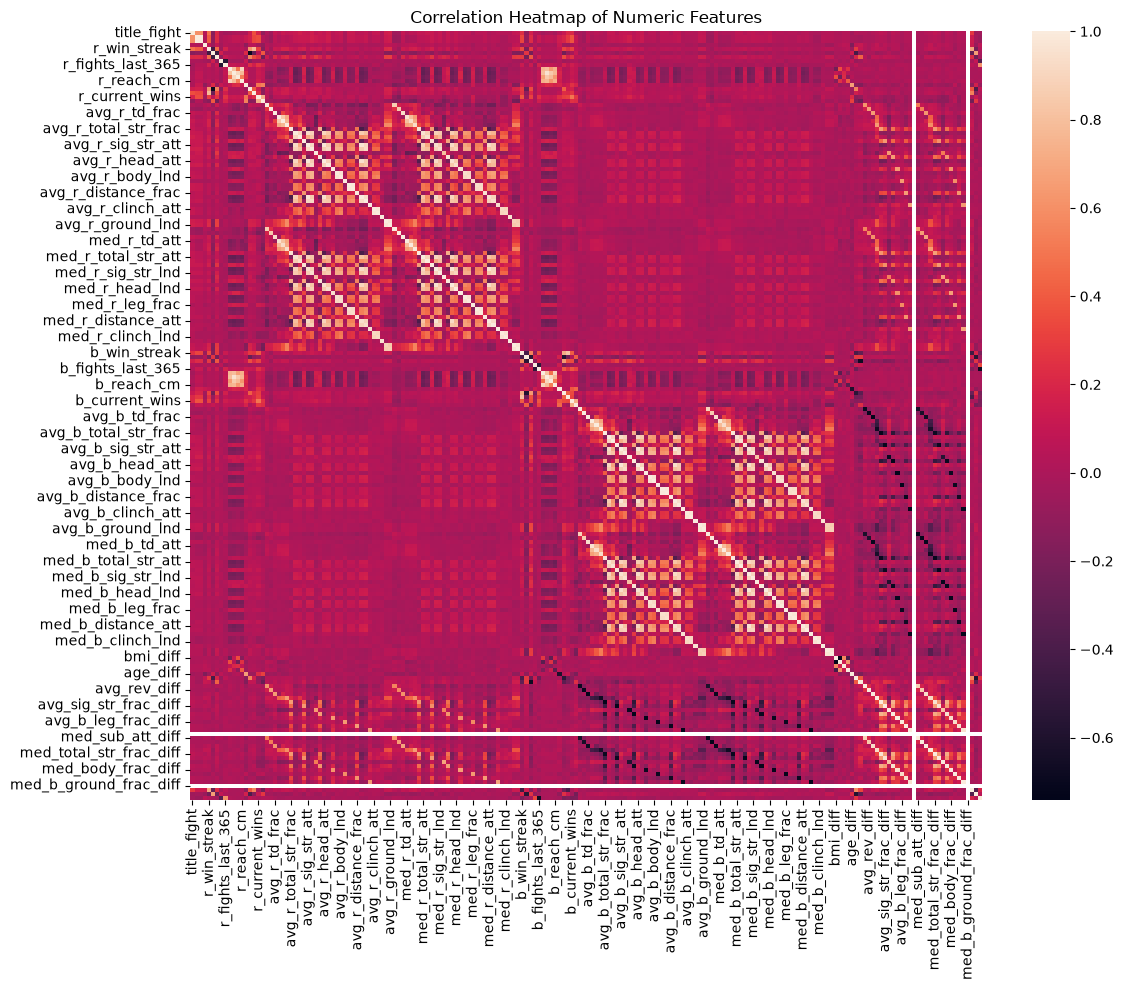

In [16]:
corr_matrix = full_ufc_selected.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix)

plt.title("Correlation Heatmap of Numeric Features")

plt.tight_layout()
plt.show()

# Calculate Rolling Window Cross Validation

In [17]:
# Calculate available months
date1 = full_ufc_selected["date_d"].max()
date2 = full_ufc_selected["date_d"].min()

months_diff = (
    (date1.year - date2.year) * 12 +
    (date1.month - date2.month)
)

print(
    f"Available history: {months_diff} months "
    f"({date2.date()} → {date1.date()})"
)


# Rolling window combinations
# Each tuple = (training window months, testing window months)
train_options = [6, 12, 18, 24, 36, 48, 60, 72]
test_options = [6, 12, 18, 24]

combo_params = [
    (tr, te)
    for tr, te in product(train_options, test_options)
    if tr >= te and (tr + te) < months_diff
]


results = []

for i, combination in enumerate(combo_params):

    remaining = len(combo_params) - i - 1

    print(
        f"\nCombination {i+1}/{len(combo_params)} "
        f"({remaining} remaining): {combination}"
    )

    models, preds = train_test_windows_by_month(
        full_ufc_selected,
        train_months=combination[0],
        test_months=combination[1]
    )

    print(
        f"Generated folds: {len(preds)}"
    )

    if len(preds) == 0:
        print(f"Skipping {combination}: no predictions")
        continue

    cv_metrics = evaluate_cv_predictions(preds)

    results.append(
        [
            combination,
            len(preds),
            cv_metrics["Precision"],
            cv_metrics["Recall"],
            cv_metrics["F1"],
            cv_metrics["Accuracy"],
            cv_metrics["AUC"]
        ]
    )


combination_eval = pd.DataFrame(
    results,
    columns=[
        "Combination",
        "Fold Number",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test Accuracy",
        "Test AUC"
    ]
)

Available history: 184 months (2010-01-02 → 2025-05-17)

Combination 1/26 (25 remaining): (6, 6)
Generated folds: 173

Total predictions: 38629
Duplicate predictions removed: 32035
Final evaluation fights: 6594

Combination 2/26 (24 remaining): (12, 6)
Generated folds: 167

Total predictions: 37873
Duplicate predictions removed: 31411
Final evaluation fights: 6462

Combination 3/26 (23 remaining): (12, 12)
Generated folds: 161

Total predictions: 73447
Duplicate predictions removed: 66985
Final evaluation fights: 6462

Combination 4/26 (22 remaining): (18, 6)
Generated folds: 161

Total predictions: 37062
Duplicate predictions removed: 30720
Final evaluation fights: 6342

Combination 5/26 (21 remaining): (18, 12)
Generated folds: 155

Total predictions: 71630
Duplicate predictions removed: 65288
Final evaluation fights: 6342

Combination 6/26 (20 remaining): (18, 18)
Generated folds: 149

Total predictions: 103582
Duplicate predictions removed: 97240
Final evaluation fights: 6342

Comb

# Choose the Best Combination of Train and Test Time Period (Months) in the Rolling Window

In [ ]:
combination_eval[["Train Months", "Test Months"]] = (
    pd.DataFrame(
        combination_eval["Combination"].tolist(),
        columns=["Train Months", "Test Months"],
        index=combination_eval.index
    )
)


# Best rolling window configuration
top_combo = combination_eval.sort_values(
    by="Test AUC",
    ascending=False
).iloc[0]


# Extract best parameters
best_train_months = top_combo["Train Months"]
best_test_months = top_combo["Test Months"]


# Latest available date
latest_date = full_ufc_selected["date_d"].max()


# Create latest training window
train_end = latest_date - pd.DateOffset(
    months=best_test_months
)

train_start = train_end - pd.DateOffset(
    months=best_train_months
)


train_mask = (
    (full_ufc_selected["date_d"] >= train_start) &
    (full_ufc_selected["date_d"] < train_end)
)


X_train = full_ufc_selected[train_mask].drop(
    columns=["r_win", "date_d"]
)

y_train = full_ufc_selected.loc[
    train_mask,
    "r_win"
]


print(
    f"Best window: "
    f"{best_train_months} months train / "
    f"{best_test_months} months test"
)

print(
    f"Training period: "
    f"{train_start.date()} → {train_end.date()}"
)


combination_eval.sort_values(
    by="Test F1",
    ascending=False
)

Best window: 36 months train / 6 months test
Training period: 2021-11-17 → 2024-11-17


,Combination,Fold Number,Test Precision,Test Recall,Test F1,Test Accuracy,Test AUC,Train Months,Test Months
10,"(36, 6)",143,0.585213,0.593365,0.586130,0.593365,0.608399,36,6
6,"(24, 6)",155,0.582493,0.591100,0.583673,0.591100,0.598003,24,6
9,"(24, 24)",137,0.582286,0.591424,0.583231,0.591424,0.599270,24,24
12,"(36, 18)",131,0.581986,0.590629,0.582830,0.590629,0.605859,36,18
7,"(24, 12)",149,0.581035,0.589806,0.582220,0.589806,0.599886,24,12
8,"(24, 18)",143,0.580629,0.589482,0.581801,0.589482,0.598774,24,18
17,"(48, 24)",113,0.580822,0.589299,0.581700,0.589299,0.606633,48,24
13,"(36, 24)",125,0.580094,0.589261,0.580757,0.589261,0.605015,36,24
11,"(36, 12)",137,0.579535,0.588064,0.580572,0.588064,0.604614,36,12
16,"(48, 18)",119,0.575855,0.585099,0.576621,0.585099,0.603446,48,18


# Hyperparameter Testing

In [19]:
# 0) Compute imbalance
counter = Counter(y_train)
ratio = counter[0] / counter[1]


# 2) Build a non-nan f1 scorer once
f1_weighted_nonan = make_scorer(
    f1_score,
    average="weighted",
    zero_division=0
)

sampler = optuna.samplers.TPESampler(
    multivariate=True,
    n_startup_trials=20,
    seed=42
)


study = optuna.create_study(
    sampler=sampler,
    direction="maximize"
)

def objective(trial):

    params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "verbosity": 0,
        "random_state": 42,

        "scale_pos_weight": trial.suggest_categorical(
            "scale_pos_weight",
            [1, ratio, math.sqrt(ratio)]
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            2,
            8
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.005,
            0.1,
            log=True
        ),

        "n_estimators": trial.suggest_int(
            "n_estimators",
            300,
            1200
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            50
        ),

        "gamma": trial.suggest_float(
            "gamma",
            1e-8,
            10,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-8,
            10,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-8,
            10,
            log=True
        ),

        "grow_policy": trial.suggest_categorical(
            "grow_policy",
            [
                "depthwise",
                "lossguide"
            ]
        ),

        "enable_categorical": True,
        "tree_method": "hist",
        "device": "cuda"
    }


    models, preds = train_test_windows_by_month(
        full_ufc_selected,
        train_months=36,
        test_months=12,
        model_params=params
    )

    print(combination, len(preds))


    metrics = evaluate_cv_predictions(
        preds
    )


    return metrics["AUC"]

study.optimize(
    objective,
    n_trials=100
)


print("Best F1:", study.best_value)
print("Best params:", study.best_params)



# 4) Re-fit on full data
best = XGBClassifier(
    **study.best_params,
    objective="binary:logistic",
    eval_metric="logloss",
    verbosity=0,
    enable_categorical=True,
    tree_method="hist",
    device="cuda",
    random_state=42
)


best.fit(
    X_train,
    y_train
)


fig = plot_optimization_history(study)
fig.show()

[I 2026-07-20 13:07:35,657] A new study created in memory with name: no-name-29a8e9d0-85c7-48c8-8f0a-97cf66623b71
[W 2026-07-20 13:13:28,728] Trial 0 failed with parameters: {'scale_pos_weight': 0.7568807339449541, 'max_depth': 6, 'learning_rate': 0.007979118876474874, 'n_estimators': 440, 'min_child_weight': 3, 'gamma': 0.6245760287469893, 'subsample': 0.8404460046972835, 'colsample_bytree': 0.8832290311184181, 'reg_alpha': 1.5320059381854043e-08, 'reg_lambda': 5.360294728728285, 'grow_policy': 'depthwise'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/michael/Documents/Python/my_ufc_prediction/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_9520/2327654436.py", line 110, in objective
    models, preds = train_test_windows_by_month(
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykerne

KeyboardInterrupt: 

# Final Test Split

In [ ]:
test_start = train_end
test_end   = latest_date

test_mask = (full_ufc_selected["date_d"] >= test_start) & (full_ufc_selected["date_d"] <= test_end)

X_test = full_ufc_selected[test_mask].drop(columns=["r_win", "date_d"])
y_test = full_ufc_selected[test_mask]["r_win"]


# Ensemble Best Models

In [ ]:
top_trials = sorted(study.trials, key=lambda t: t.value, reverse=True)[:10]

models = []
for t in top_trials:
    
    params = t.params
    params.update({
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "verbosity": 0,
        "enable_categorical": True,
        "tree_method": "gpu_hist",
        "random_state": 42
    })
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    models.append(model)
    print(f"Combination {top_trials.index(t) + 1} of {len(top_trials)} complete")

probs = np.mean([m.predict_proba(X_test)[:, 1] for m in models], axis=0)
preds = (probs >= 0.5).astype(int)

print(classification_report(y_test, preds))

weights = np.array([t.value for t in top_trials])
weights /= weights.sum()

probs = np.average(
    [m.predict_proba(X_test)[:, 1] for m in models],
    axis=0,
    weights=weights
)

preds = (probs >= 0.5).astype(int)

# The Top Performing Parameters

In [ ]:
# Convert Optuna trials to DataFrame
results_df = study.trials_dataframe(attrs=("number", "value", "params", "state"))

# Sort by highest F1 score
results_df = results_df.sort_values(by="value", ascending=False)

# Display top 5 trials
results_df.head(20)

# Metrics for Ensemble Model

In [ ]:
# —— 1) Unweighted ensemble —— #
# average probabilities on TRAIN
train_proba_unweighted = np.mean([m.predict_proba(X_train)[:, 1] for m in models], axis=0)
train_preds_unweighted = (train_proba_unweighted >= 0.5).astype(int)

print("Train Metrics (Unweighted Ensemble)")
print(f" Precision: {precision_score(y_train, train_preds_unweighted, average='weighted'):.3f}")
print(f" Recall:    {recall_score(y_train, train_preds_unweighted, average='weighted'):.3f}")
print(f" F1 Score:  {f1_score(y_train, train_preds_unweighted, average='weighted'):.3f}")
print(f" Accuracy:  {accuracy_score(y_train, train_preds_unweighted):.3f}")
print(f" AUC:       {roc_auc_score(y_train, train_proba_unweighted):.3f}")
print()

# —— 2) Unweighted ensemble on TEST —— #
test_proba_unweighted = np.mean([m.predict_proba(X_test)[:, 1] for m in models], axis=0)
test_preds_unweighted = (test_proba_unweighted >= 0.5).astype(int)

print("Test Metrics (Unweighted Ensemble)")
print(f" Precision: {precision_score(y_test, test_preds_unweighted, average='weighted'):.3f}")
print(f" Recall:    {recall_score(y_test, test_preds_unweighted, average='weighted'):.3f}")
print(f" F1 Score:  {f1_score(y_test, test_preds_unweighted, average='weighted'):.3f}")
print(f" Accuracy:  {accuracy_score(y_test, test_preds_unweighted):.3f}")
print(f" AUC:       {roc_auc_score(y_test, test_proba_unweighted):.3f}")
print()

# —— 3) Weighted ensemble —— #
# assume you already have `weights` from trial values
train_proba_weighted = np.average(
    [m.predict_proba(X_train)[:, 1] for m in models],
    axis=0,
    weights=weights
)
train_preds_weighted = (train_proba_weighted >= 0.5).astype(int)

print("Train Metrics (Weighted Ensemble)")
print(f" Precision: {precision_score(y_train, train_preds_weighted, average='weighted'):.3f}")
print(f" Recall:    {recall_score(y_train, train_preds_weighted, average='weighted'):.3f}")
print(f" F1 Score:  {f1_score(y_train, train_preds_weighted, average='weighted'):.3f}")
print(f" Accuracy:  {accuracy_score(y_train, train_preds_weighted):.3f}")
print(f" AUC:       {roc_auc_score(y_train, train_proba_weighted):.3f}")
print()

test_proba_weighted = np.average(
    [m.predict_proba(X_test)[:, 1] for m in models],
    axis=0,
    weights=weights
)
test_preds_weighted = (test_proba_weighted >= 0.5).astype(int)

print("Test Metrics (Weighted Ensemble)")
print(f" Precision: {precision_score(y_test, test_preds_weighted, average='weighted'):.3f}")
print(f" Recall:    {recall_score(y_test, test_preds_weighted, average='weighted'):.3f}")
print(f" F1 Score:  {f1_score(y_test, test_preds_weighted, average='weighted'):.3f}")
print(f" Accuracy:  {accuracy_score(y_test, test_preds_weighted):.3f}")
print(f" AUC:       {roc_auc_score(y_test, test_proba_weighted):.3f}")

# Threshold Testing

In [ ]:
# ——— 1) Build the ensemble from the top 10 (or 20) trials ——— #
top_trials = sorted(
    [t for t in study.trials if t.state == TrialState.COMPLETE],
    key=lambda t: t.value,
    reverse=True
)[:10]

models  = []
weights = np.array([t.value for t in top_trials])
weights = weights / weights.sum()

for t in top_trials:
    params = t.params.copy()
    params.update({
        "objective":         "binary:logistic",
        "eval_metric":       "logloss",
        "verbosity":         0,
        "enable_categorical": True,
        "tree_method":       "gpu_hist",
        "random_state":      42
    })
    clf = XGBClassifier(**params)
    clf.fit(X_train, y_train)
    models.append(clf)

# ——— 2) Compute ensemble probabilities on train and test ——— #
# Unweighted
y_proba_train = np.mean(
    [m.predict_proba(X_train)[:, 1] for m in models],
    axis=0
)
y_proba_test = np.mean(
    [m.predict_proba(X_test)[:, 1] for m in models],
    axis=0
)
# — if you prefer weighted:
# y_proba_train = np.average([...], axis=0, weights=weights)
# y_proba_test  = np.average([...], axis=0, weights=weights)

# ——— 3) Sweep thresholds and choose best by test F1 ——— #
thresholds = np.arange(0.00, 1.01, 0.05)
precisions, recalls, f1s = [], [], []

for th in thresholds:
    preds = (y_proba_test >= th).astype(int)
    precisions.append( precision_score(y_test, preds, average='weighted') )
    recalls.append(    recall_score(   y_test, preds, average='weighted') )
    f1s.append(        f1_score(       y_test, preds, average='weighted') )

best_idx = np.argmax(f1s)
best_th, best_f1 = thresholds[best_idx], f1s[best_idx]
print(f"Best threshold by F1 on test: {best_th:.2f} → F1={best_f1:.3f}")

# ——— 4) Plot confusion matrix at best_th ——— #
y_pred_test  = (y_proba_test  >= best_th).astype(int)
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Ensemble Confusion Matrix @th={best_th:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ——— 5) Print test & train metrics at best_th ——— #
print("Test Metrics (Ensemble)")
print(f" Precision: {precision_score(y_test,  y_pred_test,  average='weighted'):.3f}")
print(f" Recall:    {recall_score(y_test,     y_pred_test,  average='weighted'):.3f}")
print(f" F1 Score:  {f1_score(y_test,        y_pred_test,  average='weighted'):.3f}")
print(f" Accuracy:  {accuracy_score(y_test,   y_pred_test):.3f}")
print(f" AUC:       {roc_auc_score(y_test,    y_proba_test):.3f}")
print()

y_pred_train = (y_proba_train >= best_th).astype(int)
print("Train Metrics (Ensemble)")
print(f" Precision: {precision_score(y_train, y_pred_train, average='weighted'):.3f}")
print(f" Recall:    {recall_score(y_train,    y_pred_train, average='weighted'):.3f}")
print(f" F1 Score:  {f1_score(y_train,       y_pred_train, average='weighted'):.3f}")
print(f" Accuracy:  {accuracy_score(y_train,  y_pred_train):.3f}")
print(f" AUC:       {roc_auc_score(y_train,   y_proba_train):.3f}")
print()

# ——— 6) Plot Precision, Recall & F1 vs Threshold ——— #
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(thresholds, precisions, label="Precision", marker="o")
ax1.plot(thresholds, recalls,    label="Recall",    marker="o")
ax1.set_xlabel("Threshold")
ax1.set_ylabel("Precision / Recall")
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(thresholds, f1s, label="F1 Score", marker="o", linestyle="--")
ax2.set_ylabel("F1 Score")
ax2.set_ylim(0, 1)

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("Ensemble: Precision, Recall & F1 vs Threshold")
plt.show()


# Final Prediction

In [ ]:
# ——— 1. Build the ensemble ——— #
top_trials = sorted(
    [t for t in study.trials if t.state == TrialState.COMPLETE],
    key=lambda t: t.value,
    reverse=True
)[:10]

models  = []
weights = np.array([t.value for t in top_trials])
weights = weights / weights.sum()

for t in top_trials:
    params = t.params.copy()
    params.update({
        "objective":         "binary:logistic",
        "eval_metric":       "logloss",
        "verbosity":         0,
        "enable_categorical": True,
        "tree_method":       "gpu_hist",
        "random_state":      42
    })
    m = XGBClassifier(**params)
    m.fit(X_train, y_train)
    models.append(m)

# ——— 2. Grab last‐fight rows for each fighter ——— #


red, blue = "max holloway", "dustin poirier"
h_last = last_row(red,  full_ufc_engineered)
b_last = last_row(blue, full_ufc_engineered)
today  = pd.Timestamp.today()

# ——— 3. Build the predict‐row dict for ALL engineered features ——— #
feat_cols = [
    c for c in full_ufc_selected.columns
    if c not in ("r_fighter","b_fighter","date_d")
]

predict_dict = {
    "title_fight":         1,
    "weight_class":      "lightweight",
    "total_round_number": 5,
}

for col in feat_cols:
    if col.startswith("r_"):
        predict_dict[col] = h_last[col]
    elif col.startswith("b_"):
        predict_dict[col] = b_last[col]
    elif col.endswith("_diff"):
        base = col[:-5]  # strip "_diff", e.g. "height"
        r_cands = [c for c in h_last.index if c.startswith("r_") and base in c]
        b_cands = [c for c in b_last.index if c.startswith("b_") and base in c]
        if len(r_cands)==1 and len(b_cands)==1:
            predict_dict[col] = h_last[r_cands[0]] - b_last[b_cands[0]]
        else:
            predict_dict[col] = 0
    else:
        predict_dict[col] = 0

# Put into DataFrame
predict_row = pd.DataFrame([predict_dict])

# ——— 4. Align to model’s exact feature order ——— #
X_pred = predict_row.reindex(
    columns=models[0].feature_names_in_,
    fill_value=0
)

# ——— 5. Cast stances to pandas categorical ——— #
for col in ("r_stance", "b_stance"):
    cats = full_ufc_selected[col].astype("category").cat.categories
    X_pred[col] = pd.Categorical(X_pred[col], categories=cats)

# ——— 6. Predict with weighted ensemble ——— #
probas = np.array([m.predict_proba(X_pred)[0,1] for m in models])
proba  = np.average(probas, weights=weights)
pred   = int(proba >= best_th)

winner = "Conor Mcgregor" if pred == 1 else "Max Holloway"
print(f"Prediction: {winner} wins")
print(f"Confidence: {proba:.2%} that Max Holloway wins")


